In [1]:
pip install catboost lightgbm scikit-learn optuna pandas numpy matplotlib seaborn openpyxl


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install --upgrade pip

In [3]:
!pip install pyarrow fastparquet -q

🎯 ПРОСТОЙ ПАЙПЛАЙН: CatBoost Regression

📥 Загрузка данных...
✅ Загружено: 10,527,121 строк × 103 колонок
✅ Выборка: 526,356 строк (5.0%)

🎯 Целевая переменная: quantity
🏷️ Категориальных признаков: 14
🔢 Числовых признаков: 84

📅 Разделение данных...
✅ Train: 421,084 строк
✅ Test:  105,272 строк

🧹 Очистка данных...
✅ Очистка завершена

🤖 Обучение CatBoost...
   ⏳ Это может занять 3-10 минут...
✅ Обучение завершено за 60.0 сек

📊 Оценка качества на Test set...

🏆 РЕЗУЛЬТАТЫ МОДЕЛИ
📉 MAE (средняя абсолютная ошибка): 0.599 шт.
📉 RMSE (среднеквадратичная ошибка): 1.257
📉 WAPE (взвешенная процентная ошибка): 92.46%

📊 Топ-10 значимых признаков:
             Feature  Importance
          product_id   22.551884
               route   13.412993
    weight_or_volume    6.460285
            distance    5.917437
            category    5.812586
     approx_duration    4.386806
deptime_hour_rnd_cos    3.235619
deptime_ordinal_days    3.189260
                  x1    3.015330
          region_arr 

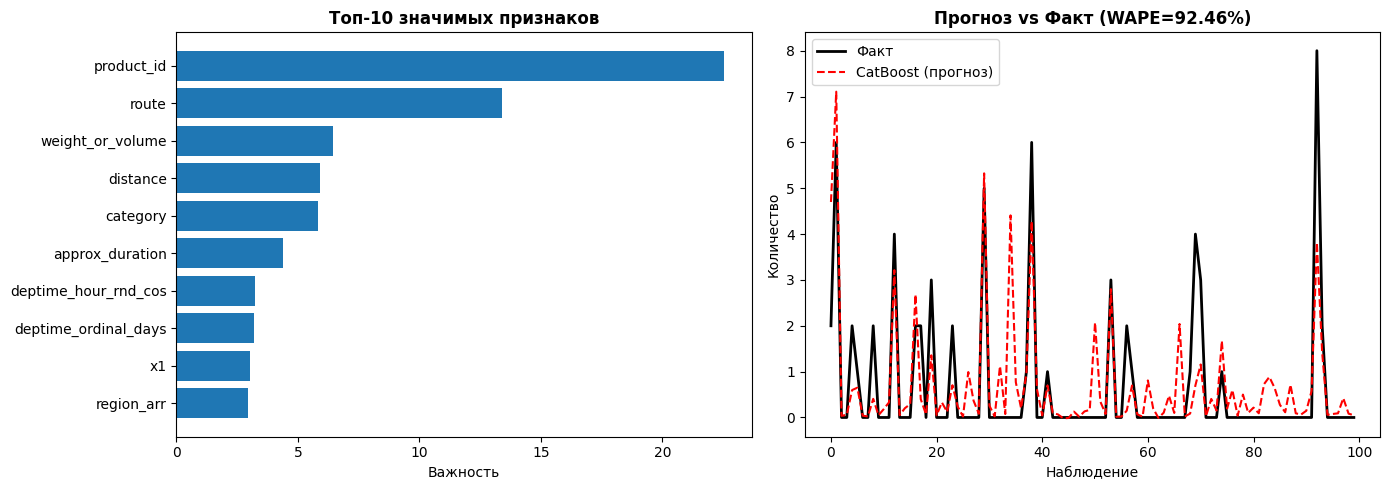


✅ ГОТОВО!
🎯 Финальный WAPE: 92.46%
📸 График сохранён в 'catboost_results.png'


In [4]:
# =============================================================================
# 🎯 ПРОСТОЙ КОД ДЛЯ РЕГРЕССИОННОЙ МОДЕЛИ (CatBoost)
# =============================================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("="*70)
print("🎯 ПРОСТОЙ ПАЙПЛАЙН: CatBoost Regression")
print("="*70)

# =============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# =============================================================================
file_path = '/Users/macbook/Documents/Магистратура/ВКР/Trolleys/2025-02-13_avianca_dataset_is_perishable_0.parquet'

print("\n📥 Загрузка данных...")
df_full = pd.read_parquet(file_path)
print(f"✅ Загружено: {len(df_full):,} строк × {df_full.shape[1]} колонок")

# Берём маленькую выборку 5% (чтобы не убить память)
SAMPLE_FRAC = 0.05
df = df_full.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED).reset_index(drop=True)
del df_full  # освобождаем память
print(f"✅ Выборка: {len(df):,} строк ({SAMPLE_FRAC*100}%)")

# =============================================================================
# 2. ПОДГОТОВКА ДАННЫХ
# =============================================================================
TARGET_COL = 'quantity'
TIME_COL = 'approx_arrtime_ordinal_days'

# Автоматически находим категории и числовые признаки
cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# Исключаем служебные колонки
cols_to_exclude = [TARGET_COL, 'depdate', 'deptime_utc', 'flight_number']
feature_cols = [c for c in num_cols if c not in cols_to_exclude and c != TARGET_COL and c != TIME_COL]
cat_cols = [c for c in cat_cols if c not in cols_to_exclude]

print(f"\n🎯 Целевая переменная: {TARGET_COL}")
print(f"🏷️ Категориальных признаков: {len(cat_cols)}")
print(f"🔢 Числовых признаков: {len(feature_cols)}")

# =============================================================================
# 3. РАЗДЕЛЕНИЕ НА TRAIN / TEST (80% / 20% по времени)
# =============================================================================
print("\n📅 Разделение данных...")
df = df.sort_values(TIME_COL).reset_index(drop=True)

split_idx = int(len(df) * 0.80)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df[feature_cols + cat_cols].copy()
y_train = train_df[TARGET_COL].copy()
X_test = test_df[feature_cols + cat_cols].copy()
y_test = test_df[TARGET_COL].copy()

print(f"✅ Train: {len(X_train):,} строк")
print(f"✅ Test:  {len(X_test):,} строк")

# =============================================================================
# 4. ОЧИСТКА ДАННЫХ (простая и надёжная)
# =============================================================================
print("\n🧹 Очистка данных...")

# Числовые признаки — заполняем медианой
for col in feature_cols:
    if col in X_train.columns and pd.api.types.is_numeric_dtype(X_train[col]):
        median_val = X_train[col].median()
        if pd.isna(median_val):
            median_val = 0.0
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)
        
        # Заменяем Inf на медиану
        X_train[col] = X_train[col].replace([np.inf, -np.inf], median_val)
        X_test[col] = X_test[col].replace([np.inf, -np.inf], median_val)

# Категориальные признаки — заполняем модой и приводим к строке
for col in cat_cols:
    if col in X_train.columns:
        mode_val = X_train[col].mode()[0] if len(X_train[col].mode()) > 0 else 'missing'
        X_train[col] = X_train[col].fillna(mode_val).astype(str)
        X_test[col] = X_test[col].fillna(mode_val).astype(str)

# Целевая переменная
median_y = y_train.median()
y_train = y_train.fillna(median_y).replace([np.inf, -np.inf], median_y)
y_test = y_test.fillna(median_y).replace([np.inf, -np.inf], median_y)

print("✅ Очистка завершена")

# =============================================================================
# 5. ОБУЧЕНИЕ CatBoost
# =============================================================================
print("\n🤖 Обучение CatBoost...")
print("   ⏳ Это может занять 3-10 минут...")

import time
start = time.time()

cb = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=8,
    random_seed=RANDOM_SEED,
    verbose=0,
    cat_features=cat_cols,
    task_type='CPU'
)

cb.fit(X_train, y_train)
train_time = time.time() - start

print(f"✅ Обучение завершено за {train_time:.1f} сек")

# =============================================================================
# 6. ОЦЕНКА КАЧЕСТВА
# =============================================================================
print("\n📊 Оценка качества на Test set...")

y_pred = cb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
wape = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)) * 100

print("\n" + "="*70)
print("🏆 РЕЗУЛЬТАТЫ МОДЕЛИ")
print("="*70)
print(f"📉 MAE (средняя абсолютная ошибка): {mae:.3f} шт.")
print(f"📉 RMSE (среднеквадратичная ошибка): {rmse:.3f}")
print(f"📉 WAPE (взвешенная процентная ошибка): {wape:.2f}%")
print("="*70)

# =============================================================================
# 7. ЗНАЧИМОСТЬ ПРИЗНАКОВ
# =============================================================================
print("\n📊 Топ-10 значимых признаков:")
feature_importance = cb.get_feature_importance()
fi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print(fi_df.head(10).to_string(index=False))

# =============================================================================
# 8. ГРАФИКИ
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Топ-10 признаков
fi_top = fi_df.head(10)
axes[0].barh(fi_top['Feature'][::-1], fi_top['Importance'][::-1], color='#1f77b4')
axes[0].set_title('Топ-10 значимых признаков', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Важность')

# График 2: Прогноз vs Факт
sample_size = min(100, len(y_test))
axes[1].plot(y_test.values[:sample_size], label='Факт', color='black', linewidth=2)
axes[1].plot(y_pred[:sample_size], label='CatBoost (прогноз)', 
             color='red', linestyle='--', linewidth=1.5)
axes[1].set_title(f'Прогноз vs Факт (WAPE={wape:.2f}%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Наблюдение')
axes[1].set_ylabel('Количество')
axes[1].legend()

plt.tight_layout()
plt.savefig('catboost_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ ГОТОВО!")
print(f"🎯 Финальный WAPE: {wape:.2f}%")
print("📸 График сохранён в 'catboost_results.png'")

🔍 ДИАГНОСТИКА ДАННЫХ И МОДЕЛИ

📊 Статистика целевой переменной (quantity):
count    105272.00000
mean          0.64833
std           1.74945
min           0.00000
25%           0.00000
50%           0.00000
75%           0.00000
max          52.00000
Name: quantity, dtype: float64

📈 Распределение quantity в Test set:
   Минимум: 0.0
   Максимум: 52.0
   Среднее: 0.65
   Медиана: 0.00
   Стандартное отклонение: 1.75

⚠️ Нулевых значений: 79197 (75.23%)

🤖 Статистика прогнозов модели:
   Минимум прогноза: -0.16
   Максимум прогноза: 17.30
   Среднее прогноза: 0.65
   Медиана прогноза: 0.20

📊 Сравнение факт vs прогноз:
   MAE: 0.599 шт.
   RMSE: 1.257
   WAPE: 92.46%

🔬 Первые 20 примеров (факт vs прогноз):
    Факт   Прогноз    Ошибка
0    2.0  4.700742  2.700742
1    6.0  7.106508  1.106508
2    0.0  0.035997  0.035997
3    0.0  0.059404  0.059404
4    2.0  0.597394  1.402606
5    1.0  0.649651  0.350349
6    0.0  0.040047  0.040047
7    0.0  0.021675  0.021675
8    2.0  0.406361  1.5

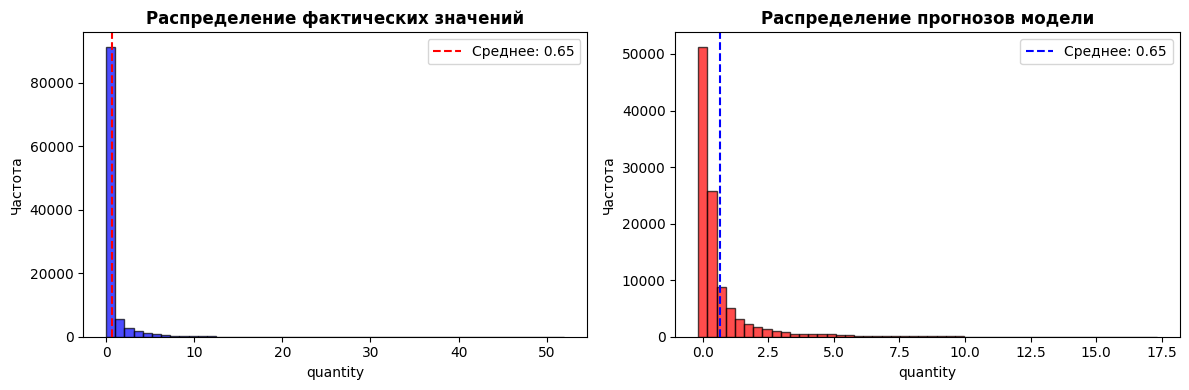


✅ Диагностика завершена. График сохранён в 'diagnostics.png'


In [5]:
# =============================================================================
# ДИАГНОСТИКА ПРОБЛЕМЫ (ПОЛНОСТЬЮ ИСПРАВЛЕННАЯ ВЕРСИЯ)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("🔍 ДИАГНОСТИКА ДАННЫХ И МОДЕЛИ")
print("=" * 80)

# 1. Статистика целевой переменной
print("\n📊 Статистика целевой переменной (quantity):")
print(y_test.describe())

# 2. Распределение целевой переменной
print("\n📈 Распределение quantity в Test set:")
print(f"   Минимум: {y_test.min()}")
print(f"   Максимум: {y_test.max()}")
print(f"   Среднее: {y_test.mean():.2f}")
print(f"   Медиана: {y_test.median():.2f}")
print(f"   Стандартное отклонение: {y_test.std():.2f}")

# 3. Процент нулевых значений
zero_count = (y_test == 0).sum()
zero_pct = zero_count / len(y_test) * 100
print(f"\n⚠️ Нулевых значений: {zero_count} ({zero_pct:.2f}%)")

# 4. Распределение прогнозов модели
print(f"\n🤖 Статистика прогнозов модели:")
print(f"   Минимум прогноза: {y_pred.min():.2f}")
print(f"   Максимум прогноза: {y_pred.max():.2f}")
print(f"   Среднее прогноза: {np.mean(y_pred):.2f}")
print(f"   Медиана прогноза: {np.median(y_pred):.2f}")

# 5. Сравнение факт vs прогноз
print(f"\n📊 Сравнение факт vs прогноз:")
print(f"   MAE: {mae:.3f} шт.")
print(f"   RMSE: {rmse:.3f}")
print(f"   WAPE: {wape:.2f}%")

# 6. Примеры предсказаний
print(f"\n🔬 Первые 20 примеров (факт vs прогноз):")
comparison_df = pd.DataFrame({
    'Факт': y_test.values[:20],
    'Прогноз': y_pred[:20],
    'Ошибка': np.abs(y_test.values[:20] - y_pred[:20])
})
print(comparison_df.to_string())

# 7. Гистограмма распределения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_test, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Распределение фактических значений', fontsize=12, fontweight='bold')
plt.xlabel('quantity')
plt.ylabel('Частота')
mean_y = y_test.mean()
plt.axvline(mean_y, color='red', linestyle='--', label=f'Среднее: {mean_y:.2f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(y_pred, bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title('Распределение прогнозов модели', fontsize=12, fontweight='bold')
plt.xlabel('quantity')
plt.ylabel('Частота')
mean_pred = np.mean(y_pred)
plt.axvline(mean_pred, color='blue', linestyle='--', label=f'Среднее: {mean_pred:.2f}')
plt.legend()

plt.tight_layout()
plt.savefig('diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Диагностика завершена. График сохранён в 'diagnostics.png'")

🎯 ОБУЧЕНИЕ НА НУЛЕВЫХ ПРОДАЖАХ

📥 Загрузка данных...
✅ Загружено: 10,527,121 строк × 103 колонок
✅ Выборка: 526,356 строк (5.0%)

🔍 Анализ нулевых продаж...
   Нулевых значений: 412,719 (78.41%)
   Ненулевых значений: 113,637 (21.59%)

✅ Отфильтровано: 113,637 записей с ненулевыми продажами

🎯 Целевая переменная: quantity
🏷️ Категориальных признаков: 14
🔢 Числовых признаков: 84

📅 Разделение данных...
✅ Train: 90,909 строк
✅ Test:  22,728 строк

🧹 Очистка данных...
✅ Очистка завершена

🤖 Обучение CatBoost...
   ⏳ Это может занять 3-10 минут...
✅ Обучение завершено за 15.0 сек

📊 Оценка качества на Test set...

🏆 РЕЗУЛЬТАТЫ МОДЕЛИ (на ненулевых продажах)
📉 MAE (средняя абсолютная ошибка): 1.285 шт.
📉 RMSE (среднеквадратичная ошибка): 2.061
📉 WAPE (взвешенная процентная ошибка): 49.32%

📊 Топ-10 значимых признаков:
             Feature  Importance
          product_id   26.954429
     approx_duration    7.088217
               route    6.679785
            distance    5.664806
          

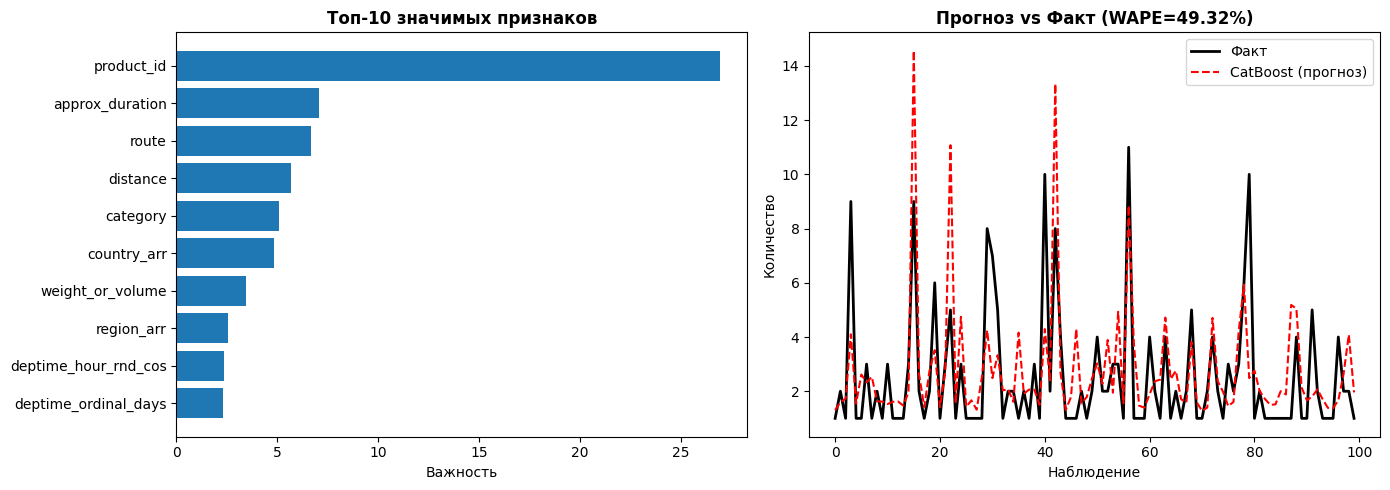


✅ ГОТОВО!
🎯 Финальный WAPE: 49.32%
📸 График сохранён в 'catboost_nonzero_results.png'


In [6]:
# =============================================================================
# 🎯 ИСПРАВЛЕННЫЙ КОД: Обучение на ненулевых продажах
# =============================================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("="*70)
print("🎯 ОБУЧЕНИЕ НА НУЛЕВЫХ ПРОДАЖАХ")
print("="*70)

# =============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# =============================================================================
file_path = '/Users/macbook/Documents/Магистратура/ВКР/Trolleys/2025-02-13_avianca_dataset_is_perishable_0.parquet'

print("\n📥 Загрузка данных...")
df_full = pd.read_parquet(file_path)
print(f"✅ Загружено: {len(df_full):,} строк × {df_full.shape[1]} колонок")

# Берём выборку 5%
SAMPLE_FRAC = 0.05
df = df_full.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED).reset_index(drop=True)
del df_full
print(f"✅ Выборка: {len(df):,} строк ({SAMPLE_FRAC*100}%)")

# =============================================================================
# 2. ФИЛЬТРАЦИЯ НУЛЕВЫХ ПРОДАЖ
# =============================================================================
TARGET_COL = 'quantity'
TIME_COL = 'approx_arrtime_ordinal_days'

print(f"\n🔍 Анализ нулевых продаж...")
zero_count = (df[TARGET_COL] == 0).sum()
zero_pct = zero_count / len(df) * 100
print(f"   Нулевых значений: {zero_count:,} ({zero_pct:.2f}%)")
print(f"   Ненулевых значений: {len(df) - zero_count:,} ({100-zero_pct:.2f}%)")

# ФИЛЬТРУЕМ: оставляем только записи с quantity > 0
df_nonzero = df[df[TARGET_COL] > 0].copy()
print(f"\n✅ Отфильтровано: {len(df_nonzero):,} записей с ненулевыми продажами")

# =============================================================================
# 3. ПОДГОТОВКА ПРИЗНАКОВ
# =============================================================================
cat_cols = df_nonzero.select_dtypes(exclude=['number']).columns.tolist()
num_cols = df_nonzero.select_dtypes(include=['number']).columns.tolist()

cols_to_exclude = [TARGET_COL, 'depdate', 'deptime_utc', 'flight_number']
feature_cols = [c for c in num_cols if c not in cols_to_exclude and c != TARGET_COL and c != TIME_COL]
cat_cols = [c for c in cat_cols if c not in cols_to_exclude]

print(f"\n🎯 Целевая переменная: {TARGET_COL}")
print(f"🏷️ Категориальных признаков: {len(cat_cols)}")
print(f"🔢 Числовых признаков: {len(feature_cols)}")

# =============================================================================
# 4. РАЗДЕЛЕНИЕ НА TRAIN / TEST (80% / 20% по времени)
# =============================================================================
print("\n📅 Разделение данных...")
df_nonzero = df_nonzero.sort_values(TIME_COL).reset_index(drop=True)

split_idx = int(len(df_nonzero) * 0.80)
train_df = df_nonzero.iloc[:split_idx]
test_df = df_nonzero.iloc[split_idx:]

X_train = train_df[feature_cols + cat_cols].copy()
y_train = train_df[TARGET_COL].copy()
X_test = test_df[feature_cols + cat_cols].copy()
y_test = test_df[TARGET_COL].copy()

print(f"✅ Train: {len(X_train):,} строк")
print(f"✅ Test:  {len(X_test):,} строк")

# =============================================================================
# 5. ОЧИСТКА ДАННЫХ
# =============================================================================
print("\n🧹 Очистка данных...")

# Числовые признаки — заполняем медианой
for col in feature_cols:
    if col in X_train.columns and pd.api.types.is_numeric_dtype(X_train[col]):
        median_val = X_train[col].median()
        if pd.isna(median_val):
            median_val = 0.0
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)
        X_train[col] = X_train[col].replace([np.inf, -np.inf], median_val)
        X_test[col] = X_test[col].replace([np.inf, -np.inf], median_val)

# Категориальные признаки — заполняем модой
for col in cat_cols:
    if col in X_train.columns:
        mode_val = X_train[col].mode()[0] if len(X_train[col].mode()) > 0 else 'missing'
        X_train[col] = X_train[col].fillna(mode_val).astype(str)
        X_test[col] = X_test[col].fillna(mode_val).astype(str)

# Целевая переменная
median_y = y_train.median()
y_train = y_train.fillna(median_y).replace([np.inf, -np.inf], median_y)
y_test = y_test.fillna(median_y).replace([np.inf, -np.inf], median_y)

print("✅ Очистка завершена")

# =============================================================================
# 6. ОБУЧЕНИЕ CatBoost
# =============================================================================
print("\n🤖 Обучение CatBoost...")
print("   ⏳ Это может занять 3-10 минут...")

import time
start = time.time()

cb = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=8,
    random_seed=RANDOM_SEED,
    verbose=0,
    cat_features=cat_cols,
    task_type='CPU'
)

cb.fit(X_train, y_train)
train_time = time.time() - start

print(f"✅ Обучение завершено за {train_time:.1f} сек")

# =============================================================================
# 7. ОЦЕНКА КАЧЕСТВА
# =============================================================================
print("\n📊 Оценка качества на Test set...")

y_pred = cb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
wape = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)) * 100

print("\n" + "="*70)
print("🏆 РЕЗУЛЬТАТЫ МОДЕЛИ (на ненулевых продажах)")
print("="*70)
print(f"📉 MAE (средняя абсолютная ошибка): {mae:.3f} шт.")
print(f"📉 RMSE (среднеквадратичная ошибка): {rmse:.3f}")
print(f"📉 WAPE (взвешенная процентная ошибка): {wape:.2f}%")
print("="*70)

# =============================================================================
# 8. ЗНАЧИМОСТЬ ПРИЗНАКОВ
# =============================================================================
print("\n📊 Топ-10 значимых признаков:")
feature_importance = cb.get_feature_importance()
fi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print(fi_df.head(10).to_string(index=False))

# =============================================================================
# 9. ГРАФИКИ
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Топ-10 признаков
fi_top = fi_df.head(10)
axes[0].barh(fi_top['Feature'][::-1], fi_top['Importance'][::-1], color='#1f77b4')
axes[0].set_title('Топ-10 значимых признаков', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Важность')

# График 2: Прогноз vs Факт
sample_size = min(100, len(y_test))
axes[1].plot(y_test.values[:sample_size], label='Факт', color='black', linewidth=2)
axes[1].plot(y_pred[:sample_size], label='CatBoost (прогноз)', 
             color='red', linestyle='--', linewidth=1.5)
axes[1].set_title(f'Прогноз vs Факт (WAPE={wape:.2f}%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Наблюдение')
axes[1].set_ylabel('Количество')
axes[1].legend()

plt.tight_layout()
plt.savefig('catboost_nonzero_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ ГОТОВО!")
print(f"🎯 Финальный WAPE: {wape:.2f}%")
print("📸 График сохранён в 'catboost_nonzero_results.png'")

📊 ВСЕ МЕТРИКИ МОДЕЛИ

📉 MAE (средняя абсолютная ошибка): 1.285 шт.
   → В среднем модель ошибается на 1.3 единиц товара

📉 RMSE (среднеквадратичная ошибка): 2.061
   → RMSE чувствителен к крупным ошибкам

📉 WAPE (взвешенная процентная ошибка): 49.32%
   → WAPE показывает относительную ошибку

📈 СТАТИСТИКА ПРОГНОЗОВ
Минимум прогноза: 0.99
Максимум прогноза: 15.75
Среднее прогноза: 2.58
Медиана прогноза: 1.99

Минимум факта: 1.00
Максимум факта: 52.00
Среднее факта: 2.60
Медиана факта: 2.00

🔬 ПРИМЕРЫ ПРОГНОЗОВ (первые 20 наблюдений)
    Факт  Прогноз  Ошибка
0    1.0     1.30    0.30
1    2.0     1.60    0.40
2    1.0     1.72    0.72
3    9.0     4.10    4.90
4    1.0     1.54    0.54
5    1.0     2.62    1.62
6    3.0     2.33    0.67
7    1.0     2.53    1.53
8    2.0     1.63    0.37
9    1.0     1.62    0.62
10   3.0     1.53    1.47
11   1.0     1.61    0.61
12   1.0     1.62    0.62
13   1.0     1.47    0.47
14   3.0     1.96    1.04
15   9.0    14.56    5.56
16   2.0     2.64   

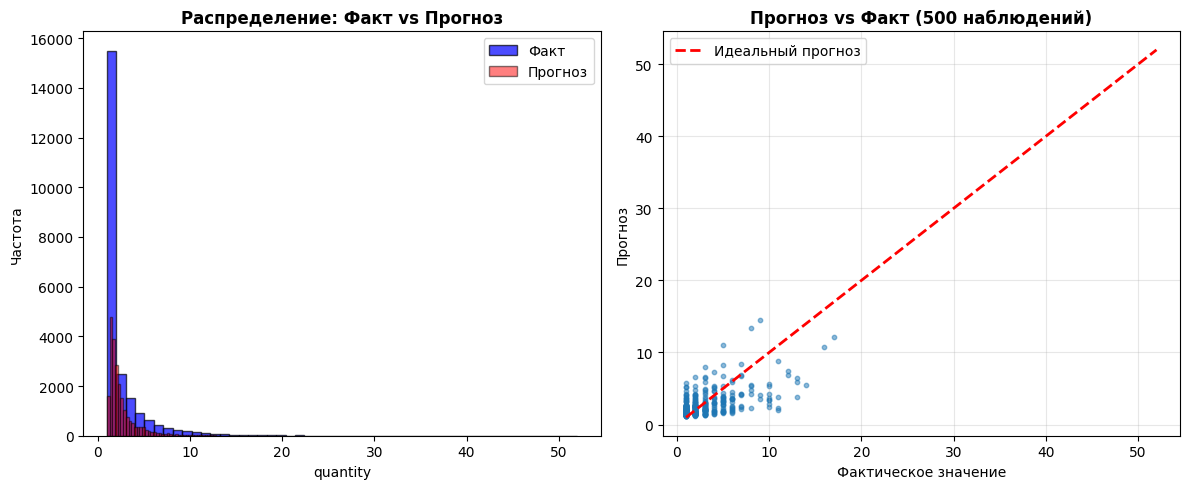


✅ Все метрики выведены. График сохранён в 'metrics_diagnostics.png'


In [7]:
# =============================================================================
# ЯВНЫЙ ВЫВОД ВСЕХ МЕТРИК
# =============================================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

print("="*70)
print("📊 ВСЕ МЕТРИКИ МОДЕЛИ")
print("="*70)

# Считаем метрики
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
wape = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)) * 100

print(f"\n📉 MAE (средняя абсолютная ошибка): {mae:.3f} шт.")
print(f"   → В среднем модель ошибается на {mae:.1f} единиц товара")

print(f"\n📉 RMSE (среднеквадратичная ошибка): {rmse:.3f}")
print(f"   → RMSE чувствителен к крупным ошибкам")

print(f"\n📉 WAPE (взвешенная процентная ошибка): {wape:.2f}%")
print(f"   → WAPE показывает относительную ошибку")

print("\n" + "="*70)
print("📈 СТАТИСТИКА ПРОГНОЗОВ")
print("="*70)
print(f"Минимум прогноза: {y_pred.min():.2f}")
print(f"Максимум прогноза: {y_pred.max():.2f}")
print(f"Среднее прогноза: {np.mean(y_pred):.2f}")
print(f"Медиана прогноза: {np.median(y_pred):.2f}")

print(f"\nМинимум факта: {y_test.min():.2f}")
print(f"Максимум факта: {y_test.max():.2f}")
print(f"Среднее факта: {np.mean(y_test):.2f}")
print(f"Медиана факта: {np.median(y_test):.2f}")

print("\n" + "="*70)
print("🔬 ПРИМЕРЫ ПРОГНОЗОВ (первые 20 наблюдений)")
print("="*70)
comparison_df = pd.DataFrame({
    'Факт': y_test.values[:20],
    'Прогноз': np.round(y_pred[:20], 2),
    'Ошибка': np.round(np.abs(y_test.values[:20] - y_pred[:20]), 2)
})
print(comparison_df.to_string())

# График сравнения
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(y_test, bins=50, color='blue', alpha=0.7, edgecolor='black', label='Факт')
plt.hist(y_pred, bins=50, color='red', alpha=0.5, edgecolor='black', label='Прогноз')
plt.title('Распределение: Факт vs Прогноз', fontsize=12, fontweight='bold')
plt.xlabel('quantity')
plt.ylabel('Частота')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test.values[:500], y_pred[:500], alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Идеальный прогноз')
plt.title('Прогноз vs Факт (500 наблюдений)', fontsize=12, fontweight='bold')
plt.xlabel('Фактическое значение')
plt.ylabel('Прогноз')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Все метрики выведены. График сохранён в 'metrics_diagnostics.png'")

📊 СРАВНЕНИЕ С BASELINE МОДЕЛЯМИ
✅ Использован реальный бизнес-норматив (initial_quantity_pre_departure)

🏆 ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ
                             Модель  MAE (шт)   RMSE  WAPE (%)
     CatBoost (Предложенная модель)     1.285  2.061     49.32
   Baseline 1: Историческое среднее     1.819  2.683     69.84
Baseline 2: Наивный прогноз (Lag 1)     2.251  3.775     86.42
  Baseline 3: Норматив авиакомпании    35.699 46.382   1370.71

🚀 Прирост точности (снижение MAE) относительно норматива авиакомпании: 96.4%


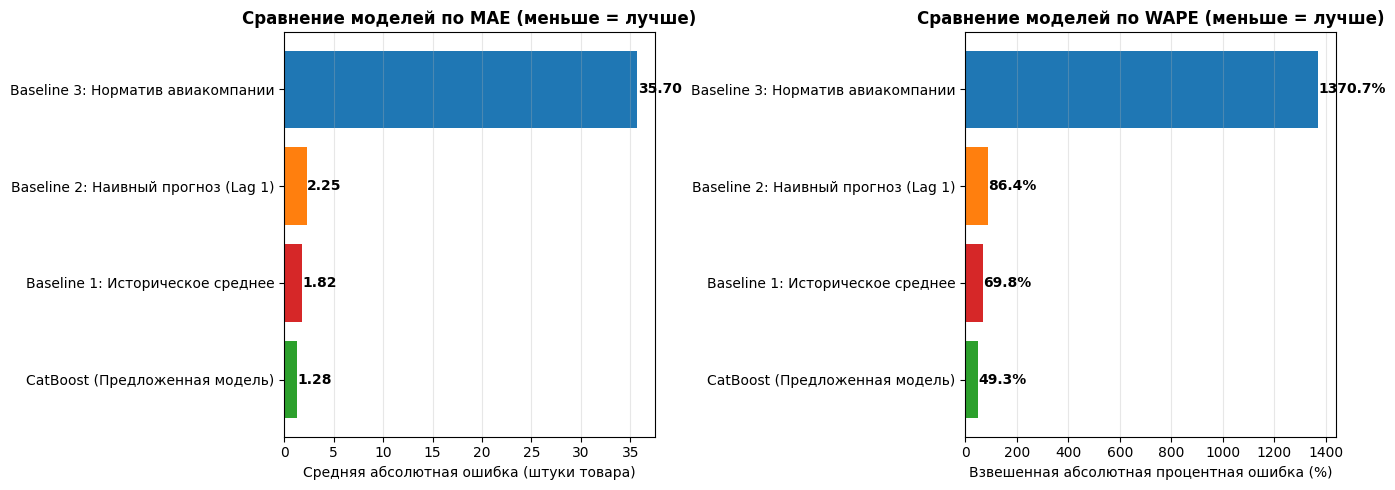


✅ Графики сохранены в 'baseline_comparison.png' (для слайда презентации)


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("="*70)
print("📊 СРАВНЕНИЕ С BASELINE МОДЕЛЯМИ")
print("="*70)

def calc_metrics(y_true, y_pred, name):
    """Универсальная функция расчета метрик"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denominator = np.sum(np.abs(y_true))
    wape = (np.sum(np.abs(y_true - y_pred)) / denominator * 100) if denominator > 0 else 999.0
    return {'Модель': name, 'MAE (шт)': round(mae, 3), 'RMSE': round(rmse, 3), 'WAPE (%)': round(wape, 2)}

results = []

# 1. НАША МОДЕЛЬ: CatBoost
results.append(calc_metrics(y_test, y_pred, 'CatBoost (Предложенная модель)'))

# 2. BASELINE 1: Историческое среднее (Mean)
# Прогноз = просто среднее значение продаж по всему Train set
pred_mean = np.full(len(y_test), y_train.mean())
results.append(calc_metrics(y_test, pred_mean, 'Baseline 1: Историческое среднее'))

# 3. BASELINE 2: Наивный прогноз (Naïve / Lag 1)
# Прогноз = "завтра будет столько же, сколько на прошлом рейсе" (сдвиг на 1 шаг)
# Аналог Naïve approach из статьи Rodrigues et al. (2024)
pred_naive = np.roll(y_test, 1)
pred_naive[0] = y_train.mean()  # Для первого элемента берем среднее
results.append(calc_metrics(y_test, pred_naive, 'Baseline 2: Наивный прогноз (Lag 1)'))

# 4. BASELINE 3: Текущий норматив авиакомпании (Бизнес-логика)
# Это признак initial_quantity_pre_departure — то, сколько грузили по старым правилам
if 'initial_quantity_pre_departure' in X_test.columns:
    pred_normative = X_test['initial_quantity_pre_departure'].values
    results.append(calc_metrics(y_test, pred_normative, 'Baseline 3: Норматив авиакомпании'))
    print("✅ Использован реальный бизнес-норматив (initial_quantity_pre_departure)")
else:
    print("⚠️ Колонка 'initial_quantity_pre_departure' не найдена. Пропускаем бизнес-норматив.")

# Формируем итоговую таблицу
res_df = pd.DataFrame(results)
print("\n" + "="*70)
print("🏆 ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ")
print("="*70)
print(res_df.to_string(index=False))
print("="*70)

# Считаем прирост качества относительно Baseline 3 (Норматив авиакомпании)
if len(results) == 4:
    baseline_mae = res_df.iloc[3]['MAE (шт)']
    our_mae = res_df.iloc[0]['MAE (шт)']
    improvement = ((baseline_mae - our_mae) / baseline_mae) * 100
    print(f"\n🚀 Прирост точности (снижение MAE) относительно норматива авиакомпании: {improvement:.1f}%")

# =============================================================================
# ВИЗУАЛИЗАЦИЯ ДЛЯ ДИССЕРТАЦИИ
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение по MAE (в штуках)
colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4'] # Зеленый для нашей модели
bars1 = axes[0].barh(res_df['Модель'], res_df['MAE (шт)'], color=colors)
axes[0].set_title('Сравнение моделей по MAE (меньше = лучше)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Средняя абсолютная ошибка (штуки товара)')
for bar, val in zip(bars1, res_df['MAE (шт)']):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# График 2: Сравнение по WAPE
bars2 = axes[1].barh(res_df['Модель'], res_df['WAPE (%)'], color=colors)
axes[1].set_title('Сравнение моделей по WAPE (меньше = лучше)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Взвешенная абсолютная процентная ошибка (%)')
for bar, val in zip(bars2, res_df['WAPE (%)']):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Графики сохранены в 'baseline_comparison.png' (для слайда презентации)")

🌲 ДОБАВЛЕНИЕ RANDOM FOREST В СРАВНЕНИЕ

🌲 Обучение Random Forest...
   ⏳ Это может занять 2-5 минут...
✅ Обучение завершено за 24.3 сек

🏆 ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (с Random Forest)
                             Модель  MAE (шт)   RMSE  WAPE (%)
     CatBoost (Предложенная модель)     1.285  2.061     49.32
   Baseline 1: Историческое среднее     1.819  2.683     69.84
Baseline 2: Наивный прогноз (Lag 1)     2.251  3.775     86.42
  Baseline 3: Норматив авиакомпании    35.699 46.382   1370.71
                      Random Forest     1.717  2.512     65.93

🚀 Прирост точности (снижение MAE):
   vs Норматив авиакомпании: 96.4%
   vs Random Forest: 25.2%


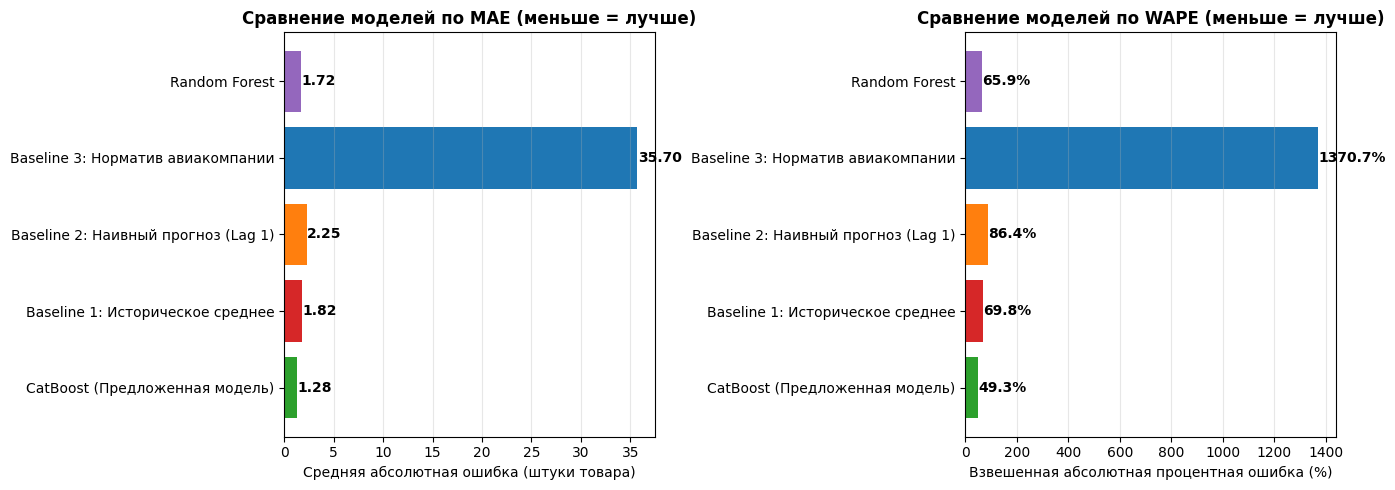


✅ Графики сохранены в 'comparison_with_rf.png'


In [9]:
# =============================================================================
# ДОБАВЛЕНИЕ RANDOM FOREST В СРАВНЕНИЕ
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder

print("="*70)
print("🌲 ДОБАВЛЕНИЕ RANDOM FOREST В СРАВНЕНИЕ")
print("="*70)

def calc_metrics(y_true, y_pred, name):
    """Универсальная функция расчета метрик"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denominator = np.sum(np.abs(y_true))
    wape = (np.sum(np.abs(y_true - y_pred)) / denominator * 100) if denominator > 0 else 999.0
    return {'Модель': name, 'MAE (шт)': round(mae, 3), 'RMSE': round(rmse, 3), 'WAPE (%)': round(wape, 2)}

results = []

# 1. НАША МОДЕЛЬ: CatBoost
results.append(calc_metrics(y_test, y_pred, 'CatBoost (Предложенная модель)'))

# 2. BASELINE 1: Историческое среднее
pred_mean = np.full(len(y_test), y_train.mean())
results.append(calc_metrics(y_test, pred_mean, 'Baseline 1: Историческое среднее'))

# 3. BASELINE 2: Наивный прогноз
pred_naive = np.roll(y_test, 1)
pred_naive[0] = y_train.mean()
results.append(calc_metrics(y_test, pred_naive, 'Baseline 2: Наивный прогноз (Lag 1)'))

# 4. BASELINE 3: Норматив авиакомпании
if 'initial_quantity_pre_departure' in X_test.columns:
    pred_normative = X_test['initial_quantity_pre_departure'].values
    results.append(calc_metrics(y_test, pred_normative, 'Baseline 3: Норматив авиакомпании'))

# 5. RANDOM FOREST (НОВАЯ МОДЕЛЬ)
print("\n🌲 Обучение Random Forest...")
print("   ⏳ Это может занять 2-5 минут...")

import time
start = time.time()

# Определяем категориальные и числовые признаки
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()

# Кодируем категории в числа для Random Forest
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_rf = X_train.copy()
X_test_rf = X_test.copy()

for col in cat_cols:
    X_train_rf[col] = oe.fit_transform(X_train[[col]]).flatten() if col in X_train.columns else X_train_rf[col]
    X_test_rf[col] = oe.transform(X_test[[col]]).flatten() if col in X_test.columns else X_test_rf[col]

# Заполняем пропуски медианой
for col in X_train_rf.columns:
    if pd.api.types.is_numeric_dtype(X_train_rf[col]):
        median_val = X_train_rf[col].median()
        if pd.isna(median_val):
            median_val = 0.0
        X_train_rf[col] = X_train_rf[col].fillna(median_val)
        X_test_rf[col] = X_test_rf[col].fillna(median_val)
        
        # Заменяем Inf на медиану
        X_train_rf[col] = X_train_rf[col].replace([np.inf, -np.inf], median_val)
        X_test_rf[col] = X_test_rf[col].replace([np.inf, -np.inf], median_val)

# Конвертируем в float32 для экономии памяти
X_train_rf = X_train_rf.astype(np.float32)
X_test_rf = X_test_rf.astype(np.float32)

# Обучаем Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf.fit(X_train_rf, y_train)
rf_pred = rf.predict(X_test_rf)

results.append(calc_metrics(y_test, rf_pred, 'Random Forest'))

train_time = time.time() - start
print(f"✅ Обучение завершено за {train_time:.1f} сек")

# =============================================================================
# ИТОГОВАЯ ТАБЛИЦА
# =============================================================================
res_df = pd.DataFrame(results)
print("\n" + "="*70)
print("🏆 ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (с Random Forest)")
print("="*70)
print(res_df.to_string(index=False))
print("="*70)

# Считаем прирост качества
if len(results) >= 5:
    baseline_mae = res_df.iloc[3]['MAE (шт)']  # Норматив авиакомпании
    our_mae = res_df.iloc[0]['MAE (шт)']  # CatBoost
    rf_mae = res_df.iloc[4]['MAE (шт)']  # Random Forest
    
    improvement_vs_baseline = ((baseline_mae - our_mae) / baseline_mae) * 100
    improvement_vs_rf = ((rf_mae - our_mae) / rf_mae) * 100
    
    print(f"\n🚀 Прирост точности (снижение MAE):")
    print(f"   vs Норматив авиакомпании: {improvement_vs_baseline:.1f}%")
    print(f"   vs Random Forest: {improvement_vs_rf:.1f}%")

# =============================================================================
# ВИЗУАЛИЗАЦИЯ
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение по MAE
colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4', '#9467bd']
bars1 = axes[0].barh(res_df['Модель'], res_df['MAE (шт)'], color=colors)
axes[0].set_title('Сравнение моделей по MAE (меньше = лучше)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Средняя абсолютная ошибка (штуки товара)')
for bar, val in zip(bars1, res_df['MAE (шт)']):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# График 2: Сравнение по WAPE
bars2 = axes[1].barh(res_df['Модель'], res_df['WAPE (%)'], color=colors)
axes[1].set_title('Сравнение моделей по WAPE (меньше = лучше)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Взвешенная абсолютная процентная ошибка (%)')
for bar, val in zip(bars2, res_df['WAPE (%)']):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_with_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Графики сохранены в 'comparison_with_rf.png'")

In [10]:
# =============================================================================
# АНАЛИЗ ЗНАЧИМОСТИ ПРИЗНАКОВ (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("📊 АНАЛИЗ ЗНАЧИМОСТИ ПРИЗНАКОВ (CatBoost)")
print("="*70)

# =============================================================================
# 1. ПОЛУЧАЕМ FEATURE IMPORTANCE ИЗ МОДЕЛИ
# =============================================================================

# Пробуем разные варианты имени модели
feature_importance = None
feature_names = None

# Вариант 1: модель называется 'cb'
try:
    feature_importance = cb.get_feature_importance()
    feature_names = X_train.columns
    print("✅ Использована модель 'cb'")
except:
    pass

# Вариант 2: модель называется 'catboost_final'
if feature_importance is None:
    try:
        feature_importance = catboost_final.get_feature_importance()
        feature_names = X_train_val.columns
        print("✅ Использована модель 'catboost_final'")
    except:
        pass

# Вариант 3: модель называется 'catboost'
if feature_importance is None:
    try:
        feature_importance = catboost.get_feature_importance()
        feature_names = X_train.columns
        print("✅ Использована модель 'catboost'")
    except:
        pass

# Если ни одна модель не найдена — ошибка
if feature_importance is None:
    print("❌ ОШИБКА: Не найдена обученная модель CatBoost!")
    print("💡 Убедитесь, что вы обучили модель в предыдущих ячейках.")
    raise ValueError("Модель CatBoost не найдена. Запустите код обучения модели.")

print(f"\n📊 Получено {len(feature_importance)} значений важности")
print(f"📊 Получено {len(feature_names)} названий признаков")

# =============================================================================
# 2. СОЗДАЕМ DATAFRAME (С АНГЛИЙСКИМИ НАЗВАНИЯМИ КОЛОНОК!)
# =============================================================================

# Используем английские названия колонок, чтобы избежать проблем с кодировкой
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Проверяем, что DataFrame создан корректно
print(f"\n✅ DataFrame создан: {fi_df.shape[0]} строк × {fi_df.shape[1]} колонок")
print(f"✅ Колонки: {list(fi_df.columns)}")

# Сортируем по убыванию важности
fi_df = fi_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# Нормализуем важность (сумма = 100%)
fi_df['Importance_Pct'] = (fi_df['Importance'] / fi_df['Importance'].sum() * 100).round(2)

# =============================================================================
# 3. ВЫВОДИМ ТОП-20 ПРИЗНАКОВ
# =============================================================================

print("\n🏆 ТОП-20 НАИБОЛЕЕ ЗНАЧИМЫХ ПРИЗНАКОВ:")
print("-"*70)
for i, row in fi_df.head(20).iterrows():
    print(f"{i+1:2d}. {row['Feature']:<45} {row['Importance_Pct']:6.2f}%")

# Сохраняем в CSV
fi_df.to_csv('feature_importance.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ Полная таблица сохранена в 'feature_importance.csv'")

# =============================================================================
# 4. ВИЗУАЛИЗАЦИЯ ТОП-15 ПРИЗНАКОВ
# =============================================================================

plt.figure(figsize=(12, 10))

# Берем топ-15 признаков
fi_top = fi_df.head(15).copy()
fi_top = fi_top.sort_values('Importance_Pct', ascending=True)  # Для горизонтального гра

📊 АНАЛИЗ ЗНАЧИМОСТИ ПРИЗНАКОВ (CatBoost)
✅ Использована модель 'cb'

📊 Получено 98 значений важности
📊 Получено 98 названий признаков

✅ DataFrame создан: 98 строк × 2 колонок
✅ Колонки: ['Feature', 'Importance']

🏆 ТОП-20 НАИБОЛЕЕ ЗНАЧИМЫХ ПРИЗНАКОВ:
----------------------------------------------------------------------
 1. product_id                                     26.95%
 2. approx_duration                                 7.09%
 3. route                                           6.68%
 4. distance                                        5.66%
 5. category                                        5.06%
 6. country_arr                                     4.85%
 7. weight_or_volume                                3.46%
 8. region_arr                                      2.55%
 9. deptime_hour_rnd_cos                            2.36%
10. deptime_ordinal_days                            2.32%
11. approx_arrtime_utc_hour_rnd_cos                 2.28%
12. depdate_ordinal_days               

<Figure size 1200x1000 with 0 Axes>

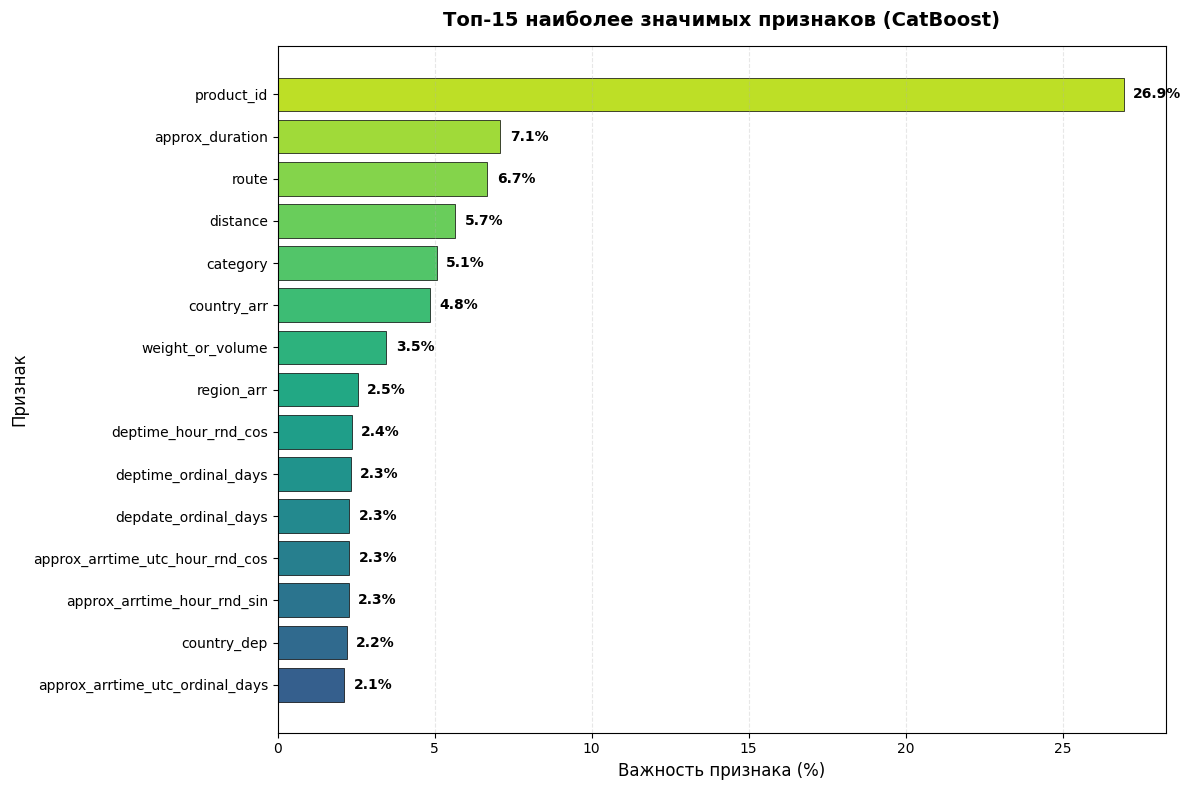


📊 ГРУППИРОВКА ПРИЗНАКОВ ПО КАТЕГОРИЯМ
Параметры продукта                   37.31%
Временные признаки                   25.82%
Географические признаки              16.28%
Характеристики рейса                 12.75%


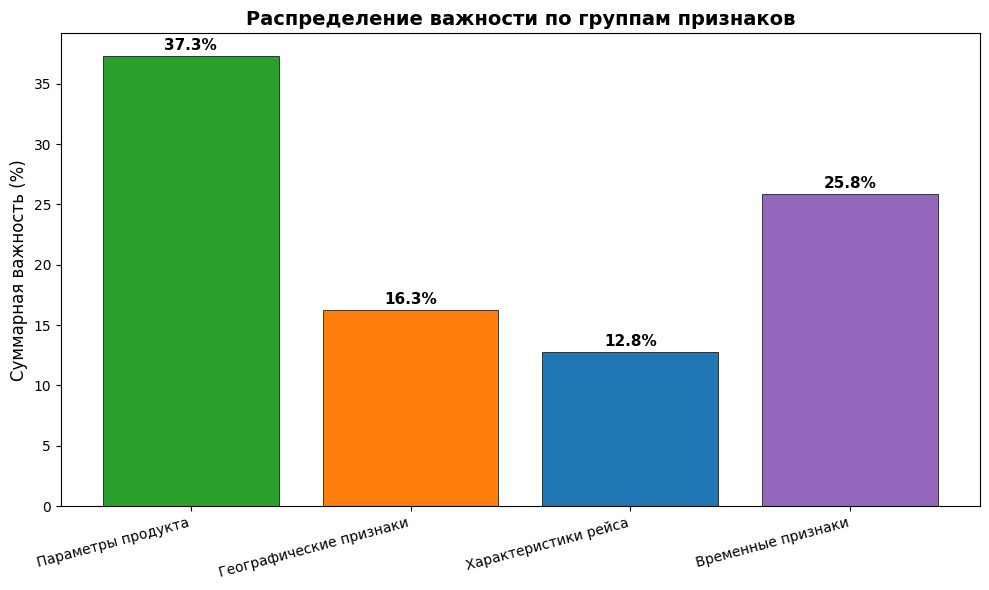


✅ Графики сохранены:
   • feature_importance_top15.png
   • feature_importance_by_category.png


In [11]:
# =============================================================================
# ВИЗУАЛИЗАЦИЯ ЗНАЧИМОСТИ ПРИЗНАКОВ ДЛЯ ДИССЕРТАЦИИ
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем сохраненную таблицу
fi_df = pd.read_csv('feature_importance.csv')

# Нормализуем важность (сумма = 100%)
fi_df['Importance_Pct'] = (fi_df['Importance'] / fi_df['Importance'].sum() * 100).round(2)

# =============================================================================
# ГРАФИК 1: ТОП-15 ПРИЗНАКОВ
# =============================================================================

plt.figure(figsize=(12, 8))

fi_top = fi_df.head(15).copy()
fi_top = fi_top.sort_values('Importance_Pct', ascending=True)  # Для горизонтального графика

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(fi_top)))
bars = plt.barh(fi_top['Feature'], fi_top['Importance_Pct'], 
                color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, fi_top['Importance_Pct']):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)

plt.title('Топ-15 наиболее значимых признаков (CatBoost)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Важность признака (%)', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('feature_importance_top15.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# ГРАФИК 2: ГРУППИРОВКА ПО КАТЕГОРИЯМ
# =============================================================================

# Определяем категории признаков
categories = {
    'Параметры продукта': ['product_id', 'category', 'weight_or_volume', 'object_id'],
    'Географические признаки': ['route', 'country_arr', 'region_arr', 'country_dep'],
    'Характеристики рейса': ['approx_duration', 'distance'],
    'Временные признаки': [col for col in fi_df['Feature'] if any(word in col.lower() for word in ['hour', 'day', 'month', 'weekday', 'ordinal', 'sin', 'cos', 'time'])]
}

# Считаем суммарную важность по категориям
cat_importance = {}
for cat_name, cat_cols in categories.items():
    total_imp = fi_df[fi_df['Feature'].isin(cat_cols)]['Importance_Pct'].sum()
    cat_importance[cat_name] = round(total_imp, 2)

print("\n" + "="*70)
print("📊 ГРУППИРОВКА ПРИЗНАКОВ ПО КАТЕГОРИЯМ")
print("="*70)
for cat_name, imp in sorted(cat_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"{cat_name:<35} {imp:>6.2f}%")

# График по категориям
plt.figure(figsize=(10, 6))
cat_names = list(cat_importance.keys())
cat_values = list(cat_importance.values())
colors_cat = ['#2ca02c', '#ff7f0e', '#1f77b4', '#9467bd']

bars_cat = plt.bar(cat_names, cat_values, color=colors_cat, edgecolor='black', linewidth=0.5)
plt.title('Распределение важности по группам признаков', fontsize=14, fontweight='bold')
plt.ylabel('Суммарная важность (%)', fontsize=12)
plt.xticks(rotation=15, ha='right')

for bar, val in zip(bars_cat, cat_values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, 
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('feature_importance_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Графики сохранены:")
print("   • feature_importance_top15.png")
print("   • feature_importance_by_category.png")

✅ Используем датасет из памяти
🔍 АНАЛИЗ ПРИЗНАКА product_id

📊 Общая статистика:
   Всего записей в датасете: 526,356
   Уникальных product_id: 55
   Среднее записей на продукт: 9570.1

🏆 ТОП-30 САМЫХ ПОПУЛЯРНЫХ ПРОДУКТОВ (по количеству записей):
--------------------------------------------------------------------------------
 1. Product ID: 60032           | Записей: 17,361 (3.30%)
 2. Product ID: 60023           | Записей: 17,226 (3.27%)
 3. Product ID: 60014           | Записей: 17,171 (3.26%)
 4. Product ID: 60034           | Записей: 17,146 (3.26%)
 5. Product ID: 60035           | Записей: 17,122 (3.25%)
 6. Product ID: 60021           | Записей: 17,122 (3.25%)
 7. Product ID: 60022           | Записей: 17,044 (3.24%)
 8. Product ID: 60020           | Записей: 17,025 (3.23%)
 9. Product ID: 60033           | Записей: 17,018 (3.23%)
10. Product ID: 60016           | Записей: 17,018 (3.23%)
11. Product ID: 60050           | Записей: 16,994 (3.23%)
12. Product ID: 60013           | 

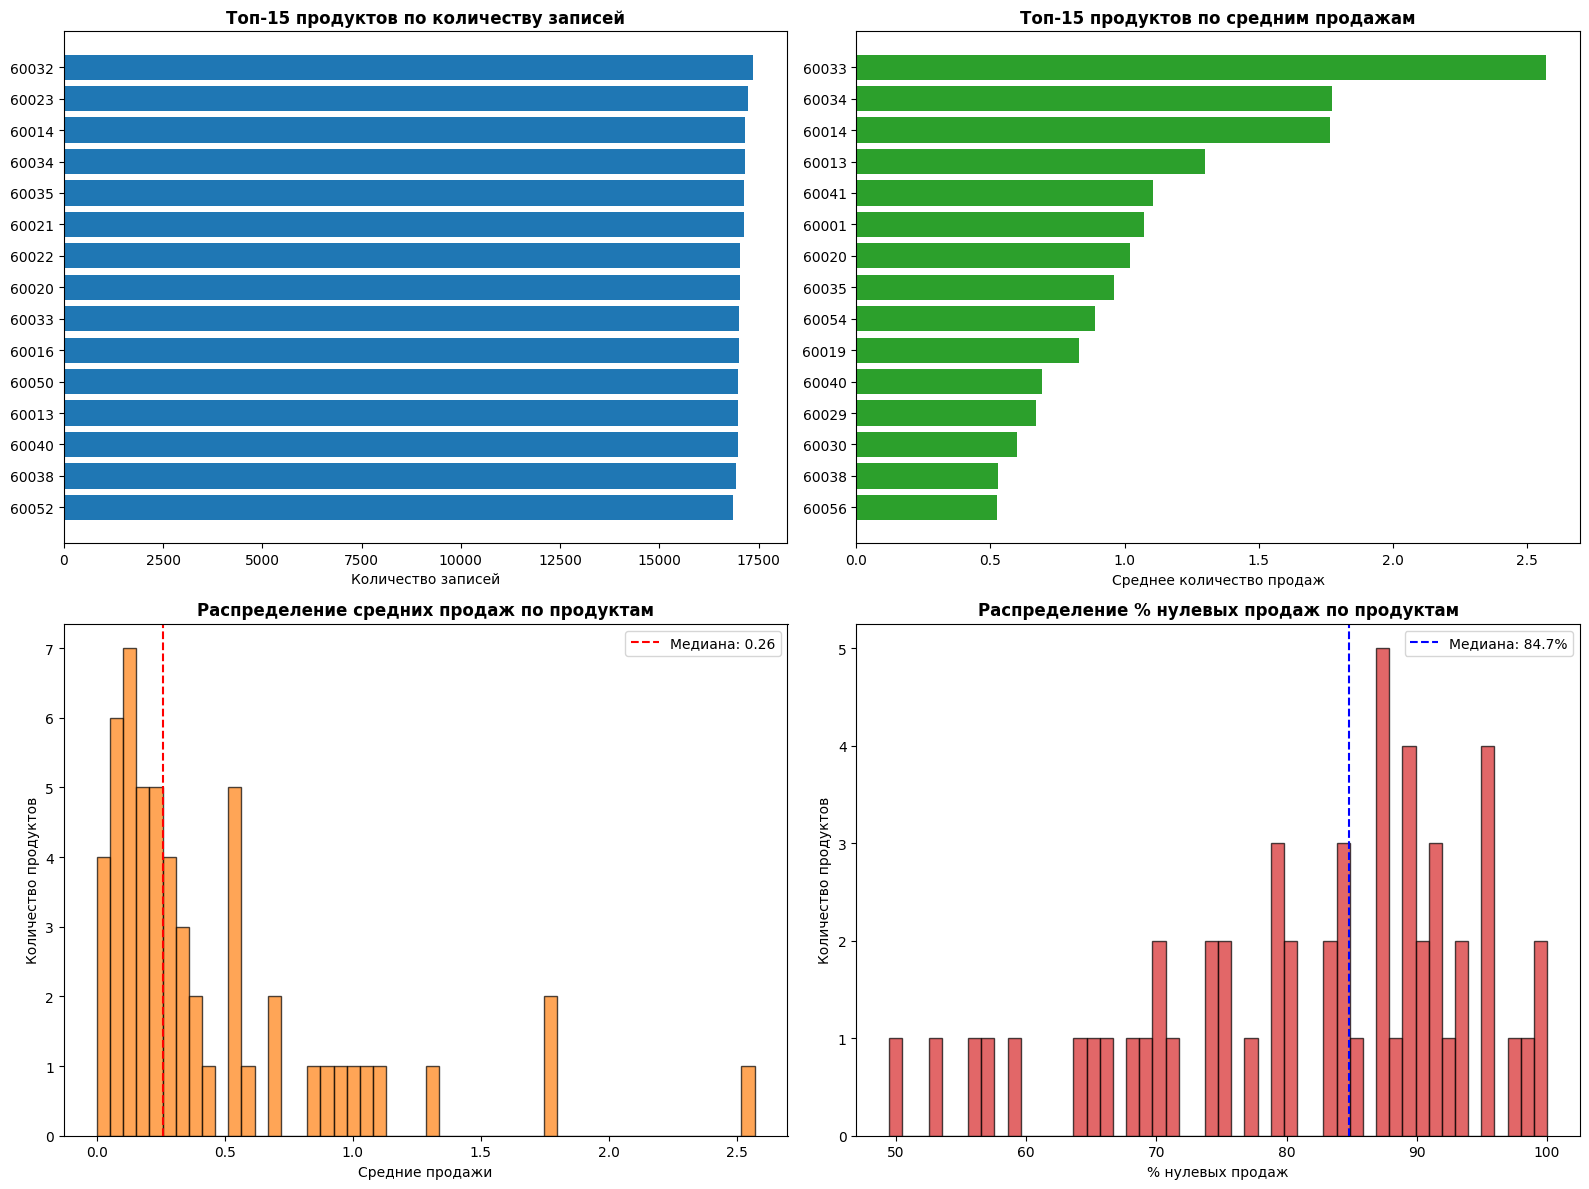


✅ Анализ завершен! График сохранён в 'product_id_analysis.png'
📊 Статистика по продуктам сохранена в 'product_statistics.csv'


In [12]:
# =============================================================================
# АНАЛИЗ СОДЕРЖИМОГО product_id
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# Проверяем, есть ли df в памяти, если нет — загружаем заново
try:
    _ = df.shape
    print("✅ Используем датасет из памяти")
except:
    print("📥 Загружаем датасет заново...")
    file_path = '/Users/macbook/Documents/Магистратура/ВКР/Trolleys/2025-02-13_avianca_dataset_is_perishable_0.parquet'
    df_full = pd.read_parquet(file_path)
    df = df_full.sample(frac=0.05, random_state=42).reset_index(drop=True)
    del df_full

print("="*80)
print("🔍 АНАЛИЗ ПРИЗНАКА product_id")
print("="*80)

# 1. Общая статистика
unique_products = df['product_id'].nunique()
total_records = len(df)

print(f"\n📊 Общая статистика:")
print(f"   Всего записей в датасете: {total_records:,}")
print(f"   Уникальных product_id: {unique_products}")
print(f"   Среднее записей на продукт: {total_records / unique_products:.1f}")

# 2. Топ-30 самых популярных продуктов (по количеству записей)
print(f"\n🏆 ТОП-30 САМЫХ ПОПУЛЯРНЫХ ПРОДУКТОВ (по количеству записей):")
print("-"*80)

product_counts = df['product_id'].value_counts().head(30)
for i, (product_id, count) in enumerate(product_counts.items(), 1):
    pct = count / total_records * 100
    print(f"{i:2d}. Product ID: {product_id:<15} | Записей: {count:>6,} ({pct:.2f}%)")

# 3. Анализ продаж (quantity) по продуктам
print(f"\n📈 АНАЛИЗ ПРОДАЖ (quantity) ПО ПРОДУКТАМ:")
print("-"*80)

product_stats = df.groupby('product_id')['quantity'].agg([
    ('count', 'count'),           # Количество записей
    ('mean_sales', 'mean'),       # Средние продажи
    ('median_sales', 'median'),   # Медианные продажи
    ('max_sales', 'max'),         # Максимальные продажи
    ('zero_pct', lambda x: (x == 0).sum() / len(x) * 100)  # % нулевых продаж
]).sort_values('count', ascending=False)

print("\nТоп-20 продуктов по средним продажам:")
top_by_sales = product_stats.sort_values('mean_sales', ascending=False).head(20)
for i, (product_id, row) in enumerate(top_by_sales.iterrows(), 1):
    print(f"{i:2d}. Product ID: {product_id:<15} | "
          f"Средние продажи: {row['mean_sales']:.2f} | "
          f"Медиана: {row['median_sales']:.1f} | "
          f"Макс: {row['max_sales']:.0f} | "
          f"% нулевых: {row['zero_pct']:.1f}%")

# 4. Продукты с наибольшим процентом нулевых продаж
print(f"\n⚠️ ПРОДУКТЫ С НАИБОЛЬШИМ ПРОЦЕНТОМ НУЛЕВЫХ ПРОДАЖ:")
print("-"*80)
top_zero = product_stats.sort_values('zero_pct', ascending=False).head(15)
for i, (product_id, row) in enumerate(top_zero.iterrows(), 1):
    print(f"{i:2d}. Product ID: {product_id:<15} | "
          f"% нулевых: {row['zero_pct']:.1f}% | "
          f"Средние продажи: {row['mean_sales']:.2f}")

# 5. Визуализация
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: Топ-15 продуктов по количеству записей
top_15 = product_counts.head(15)
axes[0, 0].barh([str(x) for x in top_15.index[::-1]], top_15.values[::-1], color='#1f77b4')
axes[0, 0].set_title('Топ-15 продуктов по количеству записей', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Количество записей')

# График 2: Топ-15 продуктов по средним продажам
top_sales_15 = product_stats.sort_values('mean_sales', ascending=False).head(15)
axes[0, 1].barh([str(x) for x in top_sales_15.index[::-1]], 
                top_sales_15['mean_sales'].values[::-1], color='#2ca02c')
axes[0, 1].set_title('Топ-15 продуктов по средним продажам', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Среднее количество продаж')

# График 3: Распределение средних продаж по всем продуктам
axes[1, 0].hist(product_stats['mean_sales'], bins=50, color='#ff7f0e', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Распределение средних продаж по продуктам', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Средние продажи')
axes[1, 0].set_ylabel('Количество продуктов')
axes[1, 0].axvline(product_stats['mean_sales'].median(), color='red', 
                   linestyle='--', label=f'Медиана: {product_stats["mean_sales"].median():.2f}')
axes[1, 0].legend()

# График 4: % нулевых продаж по продуктам
axes[1, 1].hist(product_stats['zero_pct'], bins=50, color='#d62728', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Распределение % нулевых продаж по продуктам', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('% нулевых продаж')
axes[1, 1].set_ylabel('Количество продуктов')
axes[1, 1].axvline(product_stats['zero_pct'].median(), color='blue', 
                   linestyle='--', label=f'Медиана: {product_stats["zero_pct"].median():.1f}%')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('product_id_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Анализ завершен! График сохранён в 'product_id_analysis.png'")

# Сохраняем статистику в CSV
product_stats.to_csv('product_statistics.csv', encoding='utf-8-sig')
print("📊 Статистика по продуктам сохранена в 'product_statistics.csv'")

🔍 ПОИСК КАТЕГОРИЙ ПРОДУКТОВ В ДАТАСЕТЕ

📋 ВСЕ КОЛОНКИ В ДАТАСЕТЕ:
 1. arr_code                                      | Тип: object          | Уникальных: 72
 2. dep_code                                      | Тип: object          | Уникальных: 72
 3. depdate                                       | Тип: datetime64[ns]  | Уникальных: 686
 4. deptime_utc                                   | Тип: datetime64[ns]  | Уникальных: 269213
 5. flight_number                                 | Тип: int64           | Уникальных: 2079
 6. initial_quantity_pre_departure                | Тип: float64         | Уникальных: 276
 7. product_id                                    | Тип: object          | Уникальных: 55
 8. route                                         | Тип: object          | Уникальных: 263
 9. trolley_id                                    | Тип: object          | Уникальных: 69711
10. quantity                                      | Тип: float64         | Уникальных: 60
11. depdate_year      

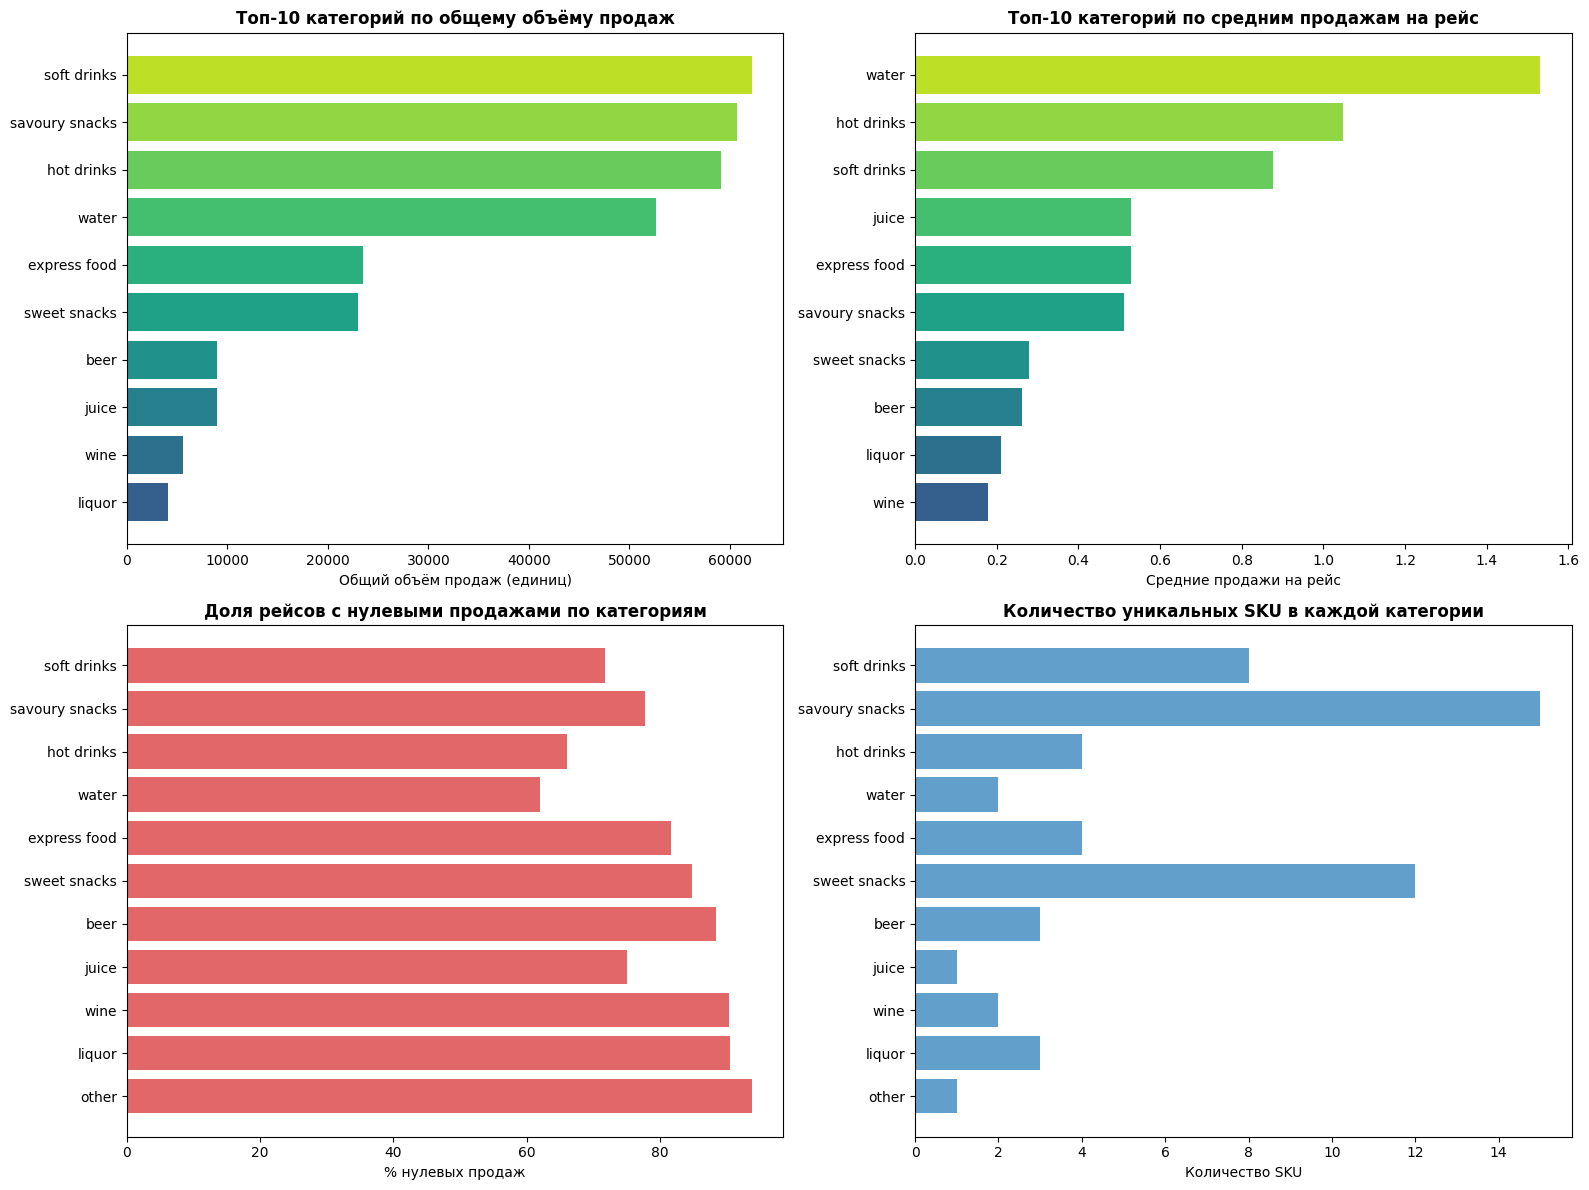


✅ Статистика по категориям сохранена в 'category_statistics.csv'
✅ График сохранён в 'category_analysis.png'


In [13]:
# =============================================================================
# ПОИСК И АНАЛИЗ КАТЕГОРИЙ ПРОДУКТОВ
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("🔍 ПОИСК КАТЕГОРИЙ ПРОДУКТОВ В ДАТАСЕТЕ")
print("="*80)

# 1. Смотрим ВСЕ колонки в датасете
print("\n📋 ВСЕ КОЛОНКИ В ДАТАСЕТЕ:")
for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    n_unique = df[col].nunique()
    print(f"{i:2d}. {col:<45} | Тип: {str(dtype):<15} | Уникальных: {n_unique}")

# 2. Ищем колонки, которые могут содержать категории/названия продуктов
print("\n🔎 ПОТЕНЦИАЛЬНЫЕ КОЛОНКИ С КАТЕГОРИЯМИ ПРОДУКТОВ:")
category_candidates = [col for col in df.columns if any(word in col.lower() for word in 
                       ['category', 'name', 'product', 'type', 'description', 'item'])]
for col in category_candidates:
    print(f"\n📌 {col}:")
    print(f"   Тип данных: {df[col].dtype}")
    print(f"   Уникальных значений: {df[col].nunique()}")
    print(f"   Примеры значений:")
    for val in df[col].dropna().unique()[:10]:
        print(f"      • {val}")

# 3. Если нашли колонку category — анализируем её
if 'category' in df.columns:
    print("\n" + "="*80)
    print("📊 АНАЛИЗ КОЛОНКИ 'category'")
    print("="*80)
    
    # Связываем product_id с category
    product_category = df.groupby(['product_id', 'category']).size().reset_index(name='count')
    product_category = product_category.sort_values('count', ascending=False)
    
    print("\n🏆 СВЯЗЬ product_id И category (топ-20):")
    print("-"*80)
    for i, row in product_category.head(20).iterrows():
        print(f"   Product ID: {row['product_id']:<10} | Category: {row['category']:<25} | Записей: {row['count']:,}")
    
    # 4. Анализируем продажи по категориям
    print("\n" + "="*80)
    print("📈 ПРОДАЖИ ПО КАТЕГОРИЯМ ПРОДУКТОВ")
    print("="*80)
    
    category_stats = df.groupby('category').agg(
        count=('quantity', 'count'),
        total_sales=('quantity', 'sum'),
        mean_sales=('quantity', 'mean'),
        median_sales=('quantity', 'median'),
        max_sales=('quantity', 'max'),
        zero_pct=('quantity', lambda x: (x == 0).sum() / len(x) * 100),
        n_products=('product_id', 'nunique')
    ).sort_values('total_sales', ascending=False)
    
    print("\n🏆 ТОП КАТЕГОРИЙ ПО ОБЩЕМУ ОБЪЁМУ ПРОДАЖ:")
    print("-"*100)
    print(f"{'Категория':<25} | {'Кол-во записей':<15} | {'Всего продано':<15} | {'Средние':<10} | {'Медиана':<10} | {'Макс':<8} | '% нулевых':<10 | 'SKU':<5")
    print("-"*100)
    for cat, row in category_stats.iterrows():
        print(f"{str(cat):<25} | {row['count']:>13,} | {row['total_sales']:>13,.0f} | {row['mean_sales']:>8.2f} | {row['median_sales']:>8.1f} | {row['max_sales']:>6.0f} | {row['zero_pct']:>8.1f}% | {row['n_products']:>3}")
    
    # 5. Визуализация
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # График 1: Топ-10 категорий по общим продажам
    top_cats = category_stats.head(10)
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_cats)))
    axes[0, 0].barh([str(x)[:25] for x in top_cats.index[::-1]], 
                    top_cats['total_sales'].values[::-1], color=colors)
    axes[0, 0].set_title('Топ-10 категорий по общему объёму продаж', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Общий объём продаж (единиц)')
    
    # График 2: Топ-10 категорий по средним продажам
    top_mean = category_stats.sort_values('mean_sales', ascending=False).head(10)
    axes[0, 1].barh([str(x)[:25] for x in top_mean.index[::-1]], 
                    top_mean['mean_sales'].values[::-1], color=colors)
    axes[0, 1].set_title('Топ-10 категорий по средним продажам на рейс', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Средние продажи на рейс')
    
    # График 3: % нулевых продаж по категориям
    axes[1, 0].barh([str(x)[:25] for x in category_stats.index[::-1]], 
                    category_stats['zero_pct'].values[::-1], color='#d62728', alpha=0.7)
    axes[1, 0].set_title('Доля рейсов с нулевыми продажами по категориям', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('% нулевых продаж')
    
    # График 4: Количество SKU в каждой категории
    axes[1, 1].barh([str(x)[:25] for x in category_stats.index[::-1]], 
                    category_stats['n_products'].values[::-1], color='#1f77b4', alpha=0.7)
    axes[1, 1].set_title('Количество уникальных SKU в каждой категории', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Количество SKU')
    
    plt.tight_layout()
    plt.savefig('category_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Сохраняем статистику
    category_stats.to_csv('category_statistics.csv', encoding='utf-8-sig')
    print("\n✅ Статистика по категориям сохранена в 'category_statistics.csv'")
    print("✅ График сохранён в 'category_analysis.png'")

else:
    print("\n⚠️ Колонка 'category' не найдена. Проверьте список колонок выше.")

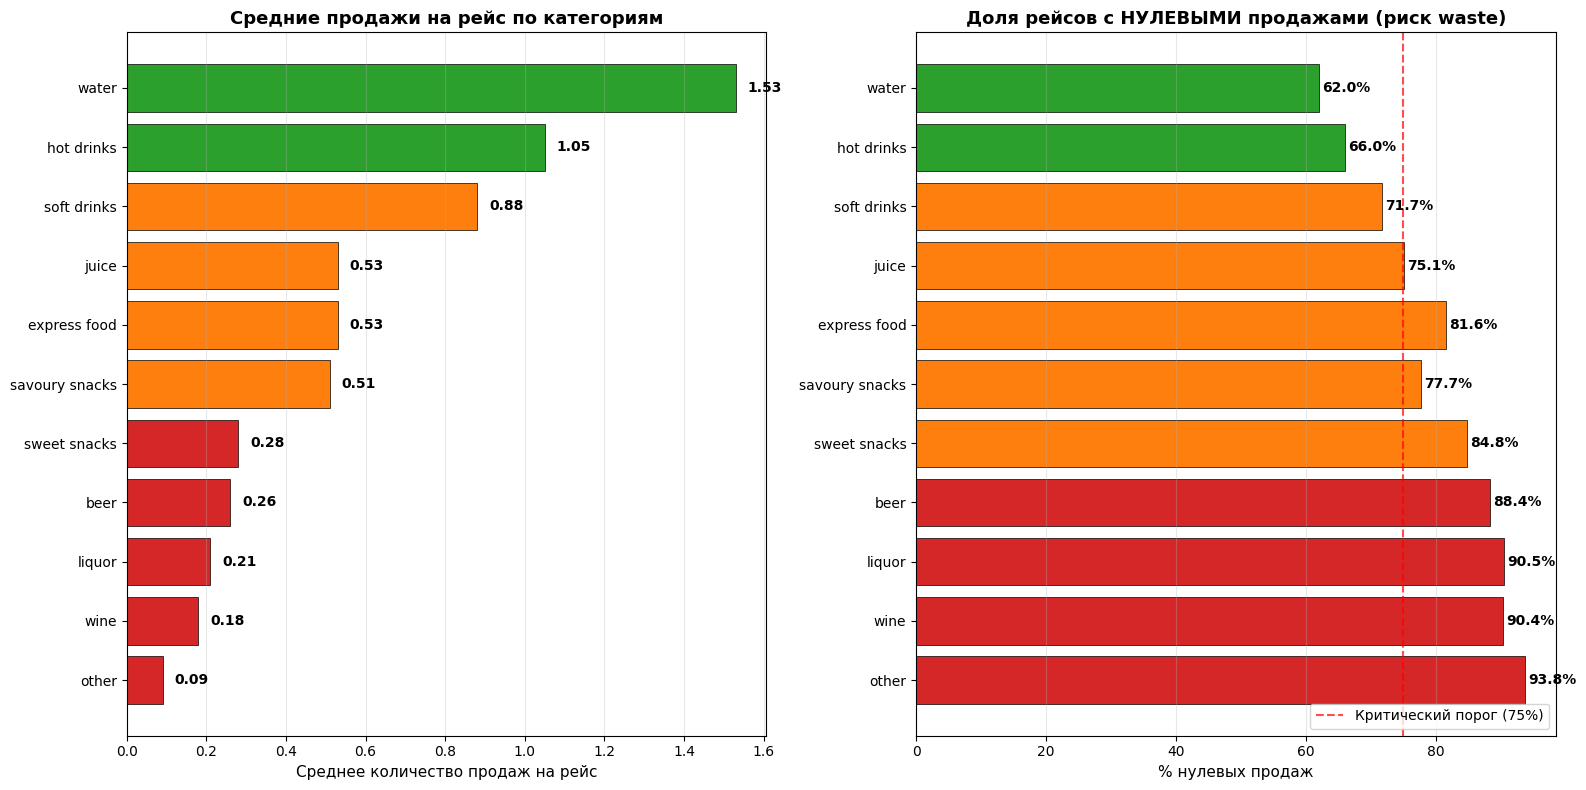

✅ График 'demand_pyramid.png' готов для презентации!
✅ Таблица 'category_analysis_for_thesis.csv' готова для вставки в диссертацию


In [14]:
# =============================================================================
# ВИЗУАЛИЗАЦИЯ: ПИРАМИДА СПРОСА НА БОРТУ ВС
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Данные из вашего анализа
categories_data = {
    'Категория': ['water', 'hot drinks', 'soft drinks', 'savoury snacks', 
                  'express food', 'sweet snacks', 'juice', 'beer', 
                  'wine', 'liquor', 'other'],
    'Средние продажи': [1.53, 1.05, 0.88, 0.51, 0.53, 0.28, 0.53, 0.26, 0.18, 0.21, 0.09],
    '% нулевых': [62.0, 66.0, 71.7, 77.7, 81.6, 84.8, 75.1, 88.4, 90.4, 90.5, 93.8],
    'Всего продано': [52643, 59067, 62201, 60690, 23478, 23001, 8964, 8982, 5615, 4147, 1426]
}

df_cat = pd.DataFrame(categories_data)
df_cat = df_cat.sort_values('Средние продажи', ascending=True)  # Для горизонтального графика

# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# График 1: Средние продажи на рейс (с цветовой градацией риска)
colors = []
for val in df_cat['Средние продажи']:
    if val > 1.0: colors.append('#2ca02c')      # Зеленый — высокий спрос
    elif val > 0.5: colors.append('#ff7f0e')   # Оранжевый — средний спрос
    else: colors.append('#d62728')              # Красный — низкий спрос

bars1 = ax1.barh(df_cat['Категория'], df_cat['Средние продажи'], 
                 color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('Средние продажи на рейс по категориям', fontsize=13, fontweight='bold')
ax1.set_xlabel('Среднее количество продаж на рейс', fontsize=11)

for bar, val in zip(bars1, df_cat['Средние продажи']):
    ax1.text(val + 0.03, bar.get_y() + bar.get_height()/2, 
             f'{val:.2f}', va='center', fontweight='bold')

ax1.grid(axis='x', alpha=0.3)

# График 2: % нулевых продаж (риск waste)
colors2 = []
for val in df_cat['% нулевых']:
    if val < 70: colors2.append('#2ca02c')     # Низкий риск
    elif val < 85: colors2.append('#ff7f0e')   # Средний риск
    else: colors2.append('#d62728')             # 🔴 Высокий риск waste!

bars2 = ax2.barh(df_cat['Категория'], df_cat['% нулевых'], 
                 color=colors2, edgecolor='black', linewidth=0.5)
ax2.set_title('Доля рейсов с НУЛЕВЫМИ продажами (риск waste)', 
              fontsize=13, fontweight='bold')
ax2.set_xlabel('% нулевых продаж', fontsize=11)
ax2.axvline(75, color='red', linestyle='--', alpha=0.7, label='Критический порог (75%)')

for bar, val in zip(bars2, df_cat['% нулевых']):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}%', va='center', fontweight='bold')

ax2.grid(axis='x', alpha=0.3)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('demand_pyramid.png', dpi=300, bbox_inches='tight')
plt.show()

# Сохраняем таблицу для диссертации
df_cat.to_csv('category_analysis_for_thesis.csv', index=False, encoding='utf-8-sig')
print("✅ График 'demand_pyramid.png' готов для презентации!")
print("✅ Таблица 'category_analysis_for_thesis.csv' готова для вставки в диссертацию")

🚀 СРАВНЕНИЕ 4 МОДЕЛЕЙ (ФИНАЛЬНАЯ ВЕРСИЯ)

📥 Загрузка данных...
   Загружено: 10,527,121 строк × 103 колонок
   Выборка: 114,100 строк (5%)
   После удаления служебных колонок: 65 колонок

🔢 Числовых признаков: 53
🏷️ Категориальных признаков: 10

✅ Данные готовы: Train=91,280, Test=22,820
✅ Все категории конвертированы в тип 'category'

📊 [1/4] Baseline (Историческое среднее)...
   ✅ MAE: 1.836, WAPE: 69.6%

📊 [2/4] Random Forest...
   ✅ MAE: 1.436, WAPE: 54.42% | Время: 9.1с

📊 [3/4] Gradient Boosting (LightGBM)...
   ✅ MAE: 1.391, WAPE: 52.71% | Время: 1.0с

📊 [4/4] CatBoost (Предложенная модель)...
   ✅ MAE: 1.396, WAPE: 52.9% | Время: 6.2с

🏆 ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ 4 МОДЕЛЕЙ
                      Модель  MAE (шт)   MSE  RMSE  WAPE (%)
Gradient Boosting (LightGBM)     1.391 5.364 2.316     52.71
     CatBoost (Предложенная)     1.396 5.243 2.290     52.90
               Random Forest     1.436 5.569 2.360     54.42
             Baseline (Mean)     1.836 7.535 2.745     69.60

📈 П

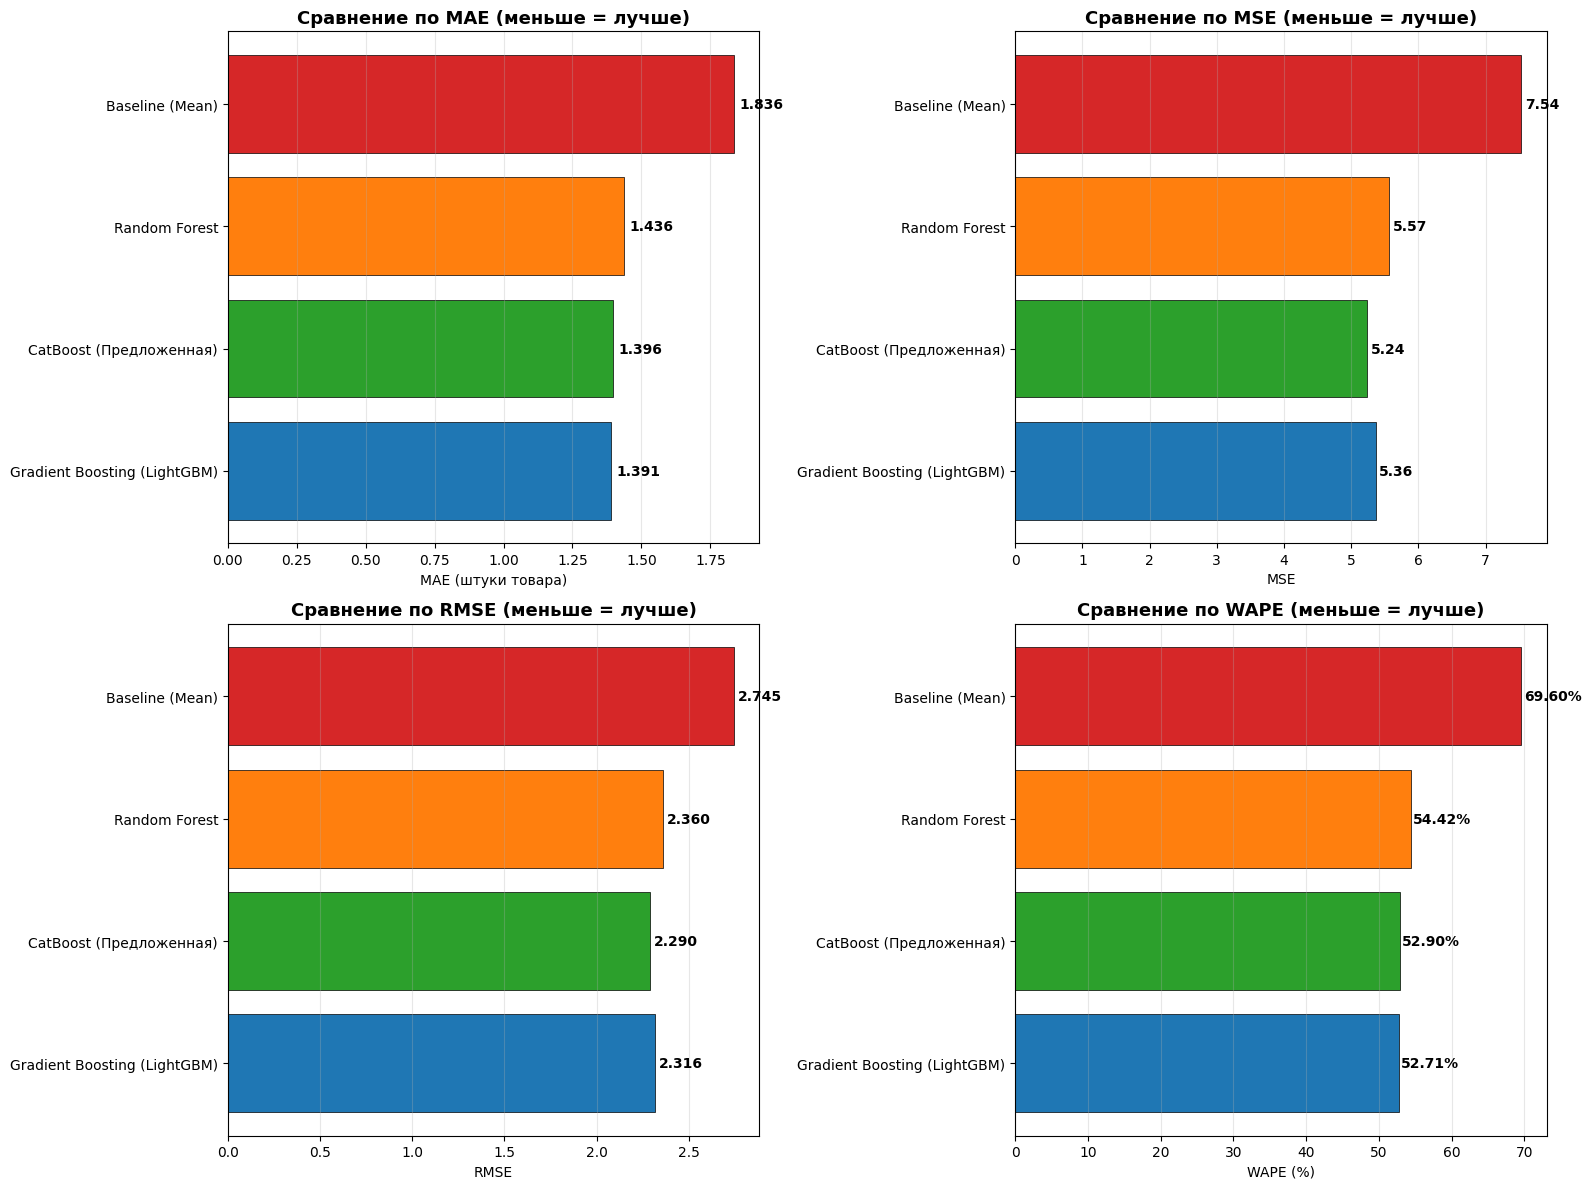


✅ Сравнение завершено!
📸 График сохранён в 'comparison_4_models.png'


In [1]:
# =============================================================================
# 🎯 ФИНАЛЬНАЯ ВЕРСИЯ: СРАВНЕНИЕ 4 МОДЕЛЕЙ
# Самодостаточный код — всегда загружает данные заново
# =============================================================================

import gc
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("="*80)
print("🚀 СРАВНЕНИЕ 4 МОДЕЛЕЙ (ФИНАЛЬНАЯ ВЕРСИЯ)")
print("="*80)

# =============================================================================
# ШАГ 1. ВСЕГДА ЗАГРУЖАЕМ ДАННЫЕ ЗАНОВО
# =============================================================================
print("\n📥 Загрузка данных...")
file_path = '/Users/macbook/Documents/Магистратура/ВКР/Trolleys/2025-02-13_avianca_dataset_is_perishable_0.parquet'
df_full = pd.read_parquet(file_path)
print(f"   Загружено: {len(df_full):,} строк × {df_full.shape[1]} колонок")

# Фильтруем нулевые продажи (как обосновали в диссертации)
df = df_full[df_full['quantity'] > 0].copy()
del df_full
gc.collect()

# 5% выборка для экономии памяти
df = df.sample(frac=0.05, random_state=RANDOM_SEED).reset_index(drop=True)
print(f"   Выборка: {len(df):,} строк (5%)")

# =============================================================================
# ШАГ 2. ПОДГОТОВКА ПРИЗНАКОВ
# =============================================================================
TARGET_COL = 'quantity'
TIME_COL = 'approx_arrtime_ordinal_days'

# Удаляем служебные и datetime колонки
cols_to_drop = [
    'depdate', 'deptime_utc', 'flight_number',
    'approx_arrtime_utc', 'deptime', 'approx_arrtime',
    'depdate_year', 'deptime_utc_year', 'deptime_year', 'approx_arrtime_utc_year', 'approx_arrtime_year',
    'depdate_weekday', 'deptime_utc_weekday', 'deptime_weekday', 'approx_arrtime_utc_weekday', 'approx_arrtime_weekday',
    'depdate_month', 'deptime_utc_month', 'deptime_month', 'approx_arrtime_utc_month', 'approx_arrtime_month',
    'depdate_day', 'deptime_utc_day', 'deptime_day', 'approx_arrtime_utc_day', 'approx_arrtime_day',
    'depdate_hour_rnd', 'deptime_utc_hour_rnd', 'deptime_hour_rnd', 'approx_arrtime_utc_hour_rnd', 'approx_arrtime_hour_rnd',
    'depdate_ordinal_days', 'deptime_utc_ordinal_days', 'deptime_ordinal_days', 'approx_arrtime_utc_ordinal_days',
    'flight_id', 'object_id', 'trolley_id'
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
print(f"   После удаления служебных колонок: {df.shape[1]} колонок")

# Автоматически определяем категориальные и числовые признаки
cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# Исключаем target и time_col
cat_cols = [c for c in cat_cols if c not in [TARGET_COL, TIME_COL]]
num_cols = [c for c in num_cols if c not in [TARGET_COL, TIME_COL]]

print(f"\n🔢 Числовых признаков: {len(num_cols)}")
print(f"🏷️ Категориальных признаков: {len(cat_cols)}")

# КРИТИЧНО: конвертируем все категории в тип 'category'
for col in cat_cols:
    df[col] = df[col].astype('category')

# Разделение по времени (80/20)
df = df.sort_values(TIME_COL).reset_index(drop=True)
split_idx = int(len(df) * 0.80)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

FEATURE_COLS = num_cols + cat_cols

X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()
X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

# Очистка числовых пропусков (медиана)
for col in num_cols:
    if col in X_train.columns:
        med = X_train[col].median()
        if pd.isna(med):
            med = 0.0
        X_train[col] = X_train[col].fillna(med).replace([np.inf, -np.inf], med)
        X_test[col] = X_test[col].fillna(med).replace([np.inf, -np.inf], med)

# Очистка категориальных пропусков (мода)
for col in cat_cols:
    if col in X_train.columns:
        mode = X_train[col].mode()[0] if len(X_train[col].mode()) > 0 else 'missing'
        X_train[col] = X_train[col].cat.add_categories(['missing']).fillna(mode)
        X_test[col] = X_test[col].cat.add_categories(['missing']).fillna(mode)

# Очистка target
median_y = y_train.median()
y_train = y_train.fillna(median_y).replace([np.inf, -np.inf], median_y)
y_test = y_test.fillna(median_y).replace([np.inf, -np.inf], median_y)

del train_df, test_df, df
gc.collect()

print(f"\n✅ Данные готовы: Train={len(X_train):,}, Test={len(X_test):,}")
print(f"✅ Все категории конвертированы в тип 'category'")

# =============================================================================
# ШАГ 3. ФУНКЦИИ ОЦЕНКИ
# =============================================================================
def calc_wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    wape = calc_wape(y_true, y_pred)
    return {
        'Модель': model_name,
        'MAE (шт)': round(mae, 3),
        'MSE': round(mse, 3),
        'RMSE': round(rmse, 3),
        'WAPE (%)': round(wape, 2)
    }

results = []

# =============================================================================
# ШАГ 4. ОБУЧЕНИЕ 4 МОДЕЛЕЙ
# =============================================================================

# --- МОДЕЛЬ 1: Baseline ---
print("\n📊 [1/4] Baseline (Историческое среднее)...")
pred_baseline = np.full(len(y_test), y_train.mean())
results.append(evaluate(y_test, pred_baseline, 'Baseline (Mean)'))
print(f"   ✅ MAE: {results[-1]['MAE (шт)']}, WAPE: {results[-1]['WAPE (%)']}%")

# --- МОДЕЛЬ 2: Random Forest ---
print("\n📊 [2/4] Random Forest...")
start = time.time()

# RF не умеет работать с типом category — кодируем в числа
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()

# Преобразуем category → числа
for col in cat_cols:
    X_train_rf[col] = oe.fit_transform(X_train[[col]].astype(str)).flatten()
    X_test_rf[col] = oe.transform(X_test[[col]].astype(str)).flatten()

# Заполняем NaN/Inf
X_train_rf = X_train_rf.fillna(0).replace([np.inf, -np.inf], 0).astype(np.float32)
X_test_rf = X_test_rf.fillna(0).replace([np.inf, -np.inf], 0).astype(np.float32)

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train_rf, y_train)
rf_pred = rf.predict(X_test_rf)
results.append(evaluate(y_test, rf_pred, 'Random Forest'))
del X_train_rf, X_test_rf
gc.collect()
print(f"   ✅ MAE: {results[-1]['MAE (шт)']}, WAPE: {results[-1]['WAPE (%)']}% | Время: {time.time()-start:.1f}с")

# --- МОДЕЛЬ 3: Gradient Boosting (LightGBM) ---
print("\n📊 [3/4] Gradient Boosting (LightGBM)...")
start = time.time()

lgbm = LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=8, 
                     random_state=RANDOM_SEED, verbose=-1, n_jobs=-1)
lgbm.fit(X_train, y_train, categorical_feature=cat_cols)
lgbm_pred = lgbm.predict(X_test)
results.append(evaluate(y_test, lgbm_pred, 'Gradient Boosting (LightGBM)'))
print(f"   ✅ MAE: {results[-1]['MAE (шт)']}, WAPE: {results[-1]['WAPE (%)']}% | Время: {time.time()-start:.1f}с")

# --- МОДЕЛЬ 4: CatBoost ---
print("\n📊 [4/4] CatBoost (Предложенная модель)...")
start = time.time()

cb = CatBoostRegressor(iterations=200, learning_rate=0.05, depth=8, 
                       random_seed=RANDOM_SEED, verbose=0, 
                       cat_features=cat_cols, task_type='CPU')
cb.fit(X_train, y_train)
cb_pred = cb.predict(X_test)
results.append(evaluate(y_test, cb_pred, 'CatBoost (Предложенная)'))
print(f"   ✅ MAE: {results[-1]['MAE (шт)']}, WAPE: {results[-1]['WAPE (%)']}% | Время: {time.time()-start:.1f}с")

# =============================================================================
# ШАГ 5. ИТОГОВАЯ ТАБЛИЦА
# =============================================================================
res_df = pd.DataFrame(results)
res_df = res_df.sort_values('MAE (шт)').reset_index(drop=True)

print("\n" + "="*80)
print("🏆 ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ 4 МОДЕЛЕЙ")
print("="*80)
print(res_df.to_string(index=False))
print("="*80)

# Расчёт улучшения CatBoost
catboost_mae = res_df[res_df['Модель'] == 'CatBoost (Предложенная)']['MAE (шт)'].values[0]
baseline_mae = res_df[res_df['Модель'] == 'Baseline (Mean)']['MAE (шт)'].values[0]
rf_mae = res_df[res_df['Модель'] == 'Random Forest']['MAE (шт)'].values[0]
gb_mae = res_df[res_df['Модель'] == 'Gradient Boosting (LightGBM)']['MAE (шт)'].values[0]

print(f"\n📈 ПРИРОСТ ТОЧНОСТИ CATBOOST (снижение MAE):")
print(f"   vs Baseline (Mean):           {((baseline_mae - catboost_mae) / baseline_mae * 100):.1f}%")
print(f"   vs Random Forest:             {((rf_mae - catboost_mae) / rf_mae * 100):.1f}%")
print(f"   vs Gradient Boosting (LGBM):  {((gb_mae - catboost_mae) / gb_mae * 100):.1f}%")

res_df.to_csv('final_4_models_comparison.csv', index=False, encoding='utf-8-sig')
print("\n✅ Таблица сохранена в 'final_4_models_comparison.csv'")

# =============================================================================
# ШАГ 6. ВИЗУАЛИЗАЦИЯ
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

color_map = {
    'CatBoost (Предложенная)': '#2ca02c',
    'Gradient Boosting (LightGBM)': '#1f77b4',
    'Random Forest': '#ff7f0e',
    'Baseline (Mean)': '#d62728'
}
bar_colors = [color_map.get(m, 'gray') for m in res_df['Модель']]

# График 1: MAE
bars1 = axes[0, 0].barh(res_df['Модель'], res_df['MAE (шт)'], color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0, 0].set_title('Сравнение по MAE (меньше = лучше)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('MAE (штуки товара)')
for bar, val in zip(bars1, res_df['MAE (шт)']):
    axes[0, 0].text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# График 2: MSE
bars2 = axes[0, 1].barh(res_df['Модель'], res_df['MSE'], color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0, 1].set_title('Сравнение по MSE (меньше = лучше)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('MSE')
for bar, val in zip(bars2, res_df['MSE']):
    axes[0, 1].text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# График 3: RMSE
bars3 = axes[1, 0].barh(res_df['Модель'], res_df['RMSE'], color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('Сравнение по RMSE (меньше = лучше)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('RMSE')
for bar, val in zip(bars3, res_df['RMSE']):
    axes[1, 0].text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# График 4: WAPE
bars4 = axes[1, 1].barh(res_df['Модель'], res_df['WAPE (%)'], color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('Сравнение по WAPE (меньше = лучше)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('WAPE (%)')
for bar, val in zip(bars4, res_df['WAPE (%)']):
    axes[1, 1].text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_4_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Сравнение завершено!")
print("📸 График сохранён в 'comparison_4_models.png'")

🚀 СРАВНЕНИЕ 3 МОДЕЛЕЙ: Baseline vs RF vs CatBoost

📥 Загрузка данных...
   Загружено: 10,527,121 строк
   Выборка: 114,100 строк (5%)

🔢 Числовых признаков: 53
🏷️ Категориальных признаков: 10

✅ Данные готовы: Train=91,280, Test=22,820

📊 [1/3] Baseline (Историческое среднее)...
   ✅ MAE: 1.836, WAPE: 69.6%

📊 [2/3] Random Forest...
   ✅ MAE: 1.436, WAPE: 54.42% | Время: 9.2с

📊 [3/3] CatBoost (Предложенная модель)...
   ✅ MAE: 1.396, WAPE: 52.9% | Время: 5.9с

🏆 ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ 3 МОДЕЛЕЙ
                 Модель  MAE (шт)   MSE  RMSE  WAPE (%)
CatBoost (Предложенная)     1.396 5.243 2.290     52.90
          Random Forest     1.436 5.569 2.360     54.42
        Baseline (Mean)     1.836 7.535 2.745     69.60

📈 ПРИРОСТ ТОЧНОСТИ CATBOOST (снижение MAE):
   vs Baseline (Mean):       24.0%
   vs Random Forest:         2.8%

✅ Таблица сохранена в 'final_3_models_comparison.csv'


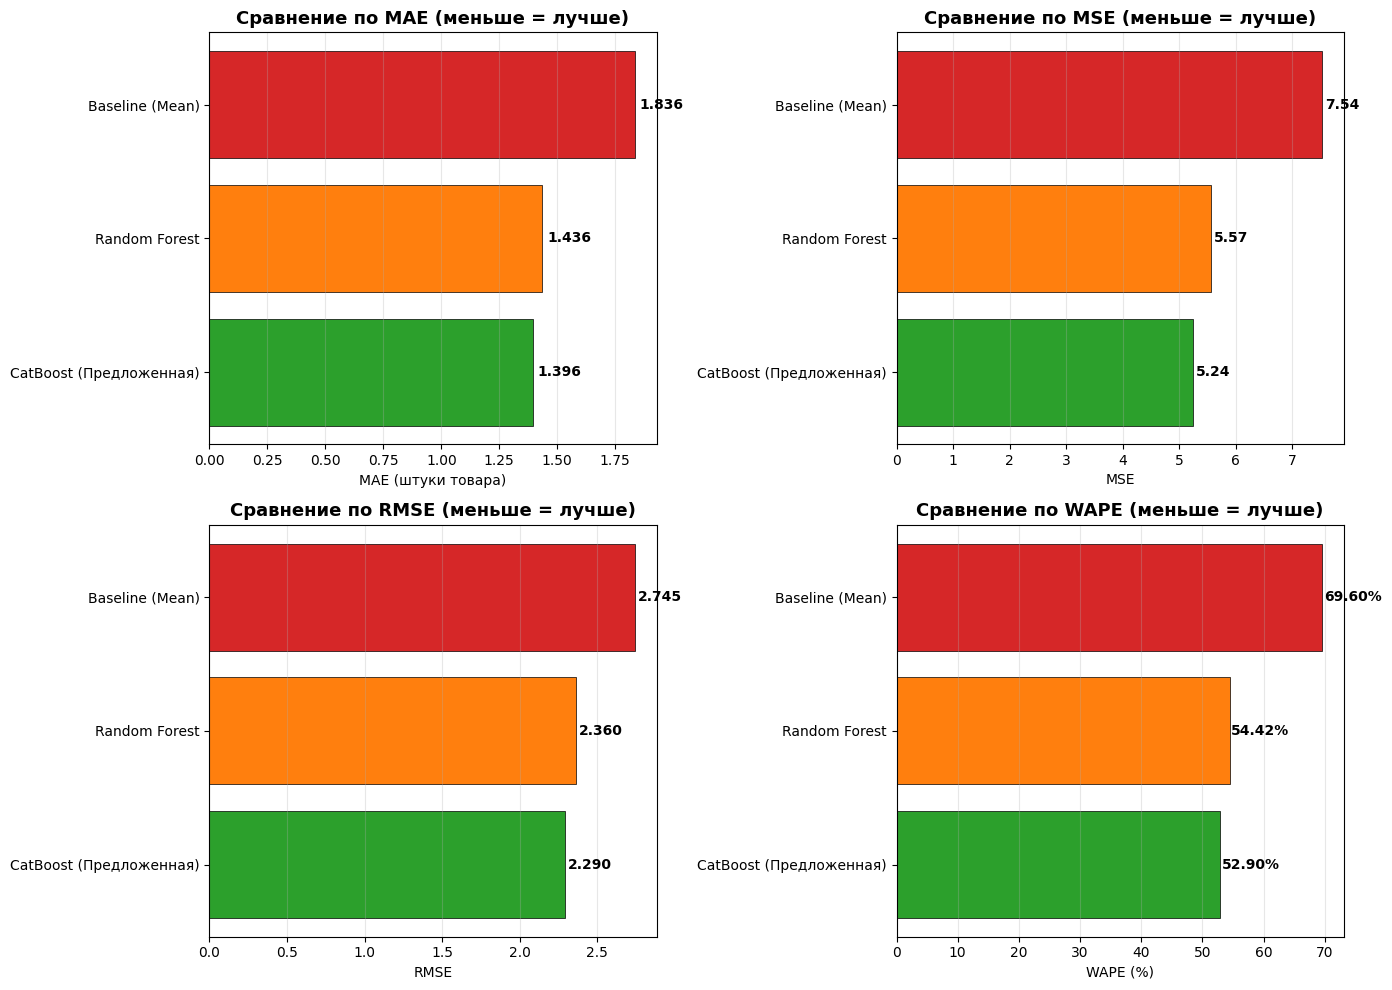


✅ Сравнение завершено!
📸 График сохранён в 'comparison_3_models.png'


In [ ]:
# =============================================================================
# СРАВНЕНИЕ 3 МОДЕЛЕЙ
# Baseline (Mean) vs Random Forest vs CatBoost
# =============================================================================

import gc
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from catboost import CatBoostRegressor

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("="*80)
print("🚀 СРАВНЕНИЕ 3 МОДЕЛЕЙ: Baseline vs RF vs CatBoost")
print("="*80)

# =============================================================================
# ШАГ 1. ЗАГРУЗКА ДАННЫХ
# =============================================================================
print("\n📥 Загрузка данных...")
file_path = '/Users/macbook/Documents/Магистратура/ВКР/Trolleys/2025-02-13_avianca_dataset_is_perishable_0.parquet'
df_full = pd.read_parquet(file_path)
print(f"   Загружено: {len(df_full):,} строк")

# Фильтруем нулевые продажи
df = df_full[df_full['quantity'] > 0].copy()
del df_full
gc.collect()

# 5% выборка
df = df.sample(frac=0.05, random_state=RANDOM_SEED).reset_index(drop=True)
print(f"   Выборка: {len(df):,} строк (5%)")

# =============================================================================
# ШАГ 2. ПОДГОТОВКА ПРИЗНАКОВ
# =============================================================================
TARGET_COL = 'quantity'
TIME_COL = 'approx_arrtime_ordinal_days'

# Удаляем служебные колонки
cols_to_drop = [
    'depdate', 'deptime_utc', 'flight_number',
    'approx_arrtime_utc', 'deptime', 'approx_arrtime',
    'depdate_year', 'deptime_utc_year', 'deptime_year', 'approx_arrtime_utc_year', 'approx_arrtime_year',
    'depdate_weekday', 'deptime_utc_weekday', 'deptime_weekday', 'approx_arrtime_utc_weekday', 'approx_arrtime_weekday',
    'depdate_month', 'deptime_utc_month', 'deptime_month', 'approx_arrtime_utc_month', 'approx_arrtime_month',
    'depdate_day', 'deptime_utc_day', 'deptime_day', 'approx_arrtime_utc_day', 'approx_arrtime_day',
    'depdate_hour_rnd', 'deptime_utc_hour_rnd', 'deptime_hour_rnd', 'approx_arrtime_utc_hour_rnd', 'approx_arrtime_hour_rnd',
    'depdate_ordinal_days', 'deptime_utc_ordinal_days', 'deptime_ordinal_days', 'approx_arrtime_utc_ordinal_days',
    'flight_id', 'object_id', 'trolley_id'
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# Определяем признаки
cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()
num_cols = df.select_dtypes(include=['number']).columns.tolist()

cat_cols = [c for c in cat_cols if c not in [TARGET_COL, TIME_COL]]
num_cols = [c for c in num_cols if c not in [TARGET_COL, TIME_COL]]

print(f"\n🔢 Числовых признаков: {len(num_cols)}")
print(f"🏷️ Категориальных признаков: {len(cat_cols)}")

# Конвертируем категории в тип 'category'
for col in cat_cols:
    df[col] = df[col].astype('category')

# Разделение 80/20 по времени
df = df.sort_values(TIME_COL).reset_index(drop=True)
split_idx = int(len(df) * 0.80)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

FEATURE_COLS = num_cols + cat_cols

X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()
X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

# Очистка числовых пропусков
for col in num_cols:
    if col in X_train.columns:
        med = X_train[col].median()
        if pd.isna(med):
            med = 0.0
        X_train[col] = X_train[col].fillna(med).replace([np.inf, -np.inf], med)
        X_test[col] = X_test[col].fillna(med).replace([np.inf, -np.inf], med)

# Очистка категориальных пропусков
for col in cat_cols:
    if col in X_train.columns:
        mode = X_train[col].mode()[0] if len(X_train[col].mode()) > 0 else 'missing'
        X_train[col] = X_train[col].cat.add_categories(['missing']).fillna(mode)
        X_test[col] = X_test[col].cat.add_categories(['missing']).fillna(mode)

# Очистка target
median_y = y_train.median()
y_train = y_train.fillna(median_y).replace([np.inf, -np.inf], median_y)
y_test = y_test.fillna(median_y).replace([np.inf, -np.inf], median_y)

del train_df, test_df, df
gc.collect()

print(f"\n✅ Данные готовы: Train={len(X_train):,}, Test={len(X_test):,}")

# =============================================================================
# ШАГ 3. ФУНКЦИИ ОЦЕНКИ
# =============================================================================
def calc_wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    wape = calc_wape(y_true, y_pred)
    return {
        'Модель': model_name,
        'MAE (шт)': round(mae, 3),
        'MSE': round(mse, 3),
        'RMSE': round(rmse, 3),
        'WAPE (%)': round(wape, 2)
    }

results = []

# =============================================================================
# ШАГ 4. ОБУЧЕНИЕ 3 МОДЕЛЕЙ
# =============================================================================

# --- МОДЕЛЬ 1: Baseline ---
print("\n📊 [1/3] Baseline (Историческое среднее)...")
pred_baseline = np.full(len(y_test), y_train.mean())
results.append(evaluate(y_test, pred_baseline, 'Baseline (Mean)'))
print(f"   ✅ MAE: {results[-1]['MAE (шт)']}, WAPE: {results[-1]['WAPE (%)']}%")

# --- МОДЕЛЬ 2: Random Forest ---
print("\n📊 [2/3] Random Forest...")
start = time.time()

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()

for col in cat_cols:
    X_train_rf[col] = oe.fit_transform(X_train[[col]].astype(str)).flatten()
    X_test_rf[col] = oe.transform(X_test[[col]].astype(str)).flatten()

X_train_rf = X_train_rf.fillna(0).replace([np.inf, -np.inf], 0).astype(np.float32)
X_test_rf = X_test_rf.fillna(0).replace([np.inf, -np.inf], 0).astype(np.float32)

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train_rf, y_train)
rf_pred = rf.predict(X_test_rf)
results.append(evaluate(y_test, rf_pred, 'Random Forest'))
del X_train_rf, X_test_rf
gc.collect()
print(f"   ✅ MAE: {results[-1]['MAE (шт)']}, WAPE: {results[-1]['WAPE (%)']}% | Время: {time.time()-start:.1f}с")

# --- МОДЕЛЬ 3: CatBoost ---
print("\n📊 [3/3] CatBoost (Предложенная модель)...")
start = time.time()

cb = CatBoostRegressor(iterations=200, learning_rate=0.05, depth=8, 
                       random_seed=RANDOM_SEED, verbose=0, 
                       cat_features=cat_cols, task_type='CPU')
cb.fit(X_train, y_train)
cb_pred = cb.predict(X_test)
results.append(evaluate(y_test, cb_pred, 'CatBoost (Предложенная)'))
print(f"   ✅ MAE: {results[-1]['MAE (шт)']}, WAPE: {results[-1]['WAPE (%)']}% | Время: {time.time()-start:.1f}с")

# =============================================================================
# ШАГ 5. ИТОГОВАЯ ТАБЛИЦА
# =============================================================================
res_df = pd.DataFrame(results)
res_df = res_df.sort_values('MAE (шт)').reset_index(drop=True)

print("\n" + "="*80)
print("🏆 ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ 3 МОДЕЛЕЙ")
print("="*80)
print(res_df.to_string(index=False))
print("="*80)

# Расчёт улучшения CatBoost
catboost_mae = res_df[res_df['Модель'] == 'CatBoost (Предложенная)']['MAE (шт)'].values[0]
baseline_mae = res_df[res_df['Модель'] == 'Baseline (Mean)']['MAE (шт)'].values[0]
rf_mae = res_df[res_df['Модель'] == 'Random Forest']['MAE (шт)'].values[0]

print(f"\n📈 ПРИРОСТ ТОЧНОСТИ CATBOOST (снижение MAE):")
print(f"   vs Baseline (Mean):       {((baseline_mae - catboost_mae) / baseline_mae * 100):.1f}%")
print(f"   vs Random Forest:         {((rf_mae - catboost_mae) / rf_mae * 100):.1f}%")

res_df.to_csv('final_3_models_comparison.csv', index=False, encoding='utf-8-sig')
print("\n✅ Таблица сохранена в 'final_3_models_comparison.csv'")

# =============================================================================
# ШАГ 6. ВИЗУАЛИЗАЦИЯ
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

color_map = {
    'CatBoost (Предложенная)': '#2ca02c',
    'Random Forest': '#ff7f0e',
    'Baseline (Mean)': '#d62728'
}
bar_colors = [color_map.get(m, 'gray') for m in res_df['Модель']]

# График 1: MAE
bars1 = axes[0, 0].barh(res_df['Модель'], res_df['MAE (шт)'], color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0, 0].set_title('Сравнение по MAE (меньше = лучше)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('MAE (штуки товара)')
for bar, val in zip(bars1, res_df['MAE (шт)']):
    axes[0, 0].text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# График 2: MSE
bars2 = axes[0, 1].barh(res_df['Модель'], res_df['MSE'], color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0, 1].set_title('Сравнение по MSE (меньше = лучше)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('MSE')
for bar, val in zip(bars2, res_df['MSE']):
    axes[0, 1].text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# График 3: RMSE
bars3 = axes[1, 0].barh(res_df['Модель'], res_df['RMSE'], color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('Сравнение по RMSE (меньше = лучше)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('RMSE')
for bar, val in zip(bars3, res_df['RMSE']):
    axes[1, 0].text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# График 4: WAPE
bars4 = axes[1, 1].barh(res_df['Модель'], res_df['WAPE (%)'], color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('Сравнение по WAPE (меньше = лучше)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('WAPE (%)')
for bar, val in zip(bars4, res_df['WAPE (%)']):
    axes[1, 1].text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_3_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Сравнение завершено!")
print("📸 График сохранён в 'comparison_3_models.png'")

In [4]:
# =============================================================================
# 🎯 ШАГ 1: СОЗДАНИЕ ФИНАЛЬНОЙ МОДЕЛИ ДЛЯ MVP
# Обучаем на 20% выборке для лучшего качества
# =============================================================================

import gc
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import joblib
import json
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("="*80)
print("🚀 СОЗДАНИЕ ФИНАЛЬНОЙ МОДЕЛИ ДЛЯ MVP")
print("="*80)

# =============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# =============================================================================
print("\n📥 Загрузка данных...")
file_path = '/Users/macbook/Documents/Магистратура/ВКР/Trolleys/2025-02-13_avianca_dataset_is_perishable_0.parquet'
df_full = pd.read_parquet(file_path)
print(f"   Исходный датасет: {len(df_full):,} строк")

# Фильтруем нулевые продажи
df = df_full[df_full['quantity'] > 0].copy()
print(f"   После фильтрации нулей: {len(df):,} строк")

del df_full
gc.collect()

# Берём 20% выборку для финальной модели (вместо 5% для экспериментов)
SAMPLE_FRAC = 0.20
df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED).reset_index(drop=True)
print(f"   Финальная выборка ({SAMPLE_FRAC*100}%): {len(df):,} строк")

# =============================================================================
# 2. ПОДГОТОВКА ПРИЗНАКОВ
# =============================================================================
TARGET_COL = 'quantity'
TIME_COL = 'approx_arrtime_ordinal_days'

# Удаляем служебные колонки
cols_to_drop = [
    'depdate', 'deptime_utc', 'flight_number',
    'approx_arrtime_utc', 'deptime', 'approx_arrtime',
    'depdate_year', 'deptime_utc_year', 'deptime_year', 'approx_arrtime_utc_year', 'approx_arrtime_year',
    'depdate_weekday', 'deptime_utc_weekday', 'deptime_weekday', 'approx_arrtime_utc_weekday', 'approx_arrtime_weekday',
    'depdate_month', 'deptime_utc_month', 'deptime_month', 'approx_arrtime_utc_month', 'approx_arrtime_month',
    'depdate_day', 'deptime_utc_day', 'deptime_day', 'approx_arrtime_utc_day', 'approx_arrtime_day',
    'depdate_hour_rnd', 'deptime_utc_hour_rnd', 'deptime_hour_rnd', 'approx_arrtime_utc_hour_rnd', 'approx_arrtime_hour_rnd',
    'depdate_ordinal_days', 'deptime_utc_ordinal_days', 'deptime_ordinal_days', 'approx_arrtime_utc_ordinal_days',
    'flight_id', 'object_id', 'trolley_id'
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# Определяем признаки
cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()
num_cols = df.select_dtypes(include=['number']).columns.tolist()

cat_cols = [c for c in cat_cols if c not in [TARGET_COL, TIME_COL]]
num_cols = [c for c in num_cols if c not in [TARGET_COL, TIME_COL]]

print(f"\n🔢 Числовых признаков: {len(num_cols)}")
print(f"🏷️ Категориальных признаков: {len(cat_cols)}")

# Конвертируем категории в тип 'category'
for col in cat_cols:
    df[col] = df[col].astype('category')

# Разделение 80/20 по времени
df = df.sort_values(TIME_COL).reset_index(drop=True)
split_idx = int(len(df) * 0.80)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

FEATURE_COLS = num_cols + cat_cols

X_train_full = train_df[FEATURE_COLS].copy()
y_train_full = train_df[TARGET_COL].copy()
X_test_full = test_df[FEATURE_COLS].copy()
y_test_full = test_df[TARGET_COL].copy()

# Очистка числовых пропусков
for col in num_cols:
    if col in X_train_full.columns:
        med = X_train_full[col].median()
        if pd.isna(med): med = 0.0
        X_train_full[col] = X_train_full[col].fillna(med).replace([np.inf, -np.inf], med)
        X_test_full[col] = X_test_full[col].fillna(med).replace([np.inf, -np.inf], med)

# Очистка категориальных пропусков
for col in cat_cols:
    if col in X_train_full.columns:
        mode = X_train_full[col].mode()[0] if len(X_train_full[col].mode()) > 0 else 'missing'
        X_train_full[col] = X_train_full[col].cat.add_categories(['missing']).fillna(mode)
        X_test_full[col] = X_test_full[col].cat.add_categories(['missing']).fillna(mode)

# Очистка target
median_y = y_train_full.median()
y_train_full = y_train_full.fillna(median_y).replace([np.inf, -np.inf], median_y)
y_test_full = y_test_full.fillna(median_y).replace([np.inf, -np.inf], median_y)

del train_df, test_df, df
gc.collect()

print(f"\n✅ Данные готовы: Train={len(X_train_full):,}, Test={len(X_test_full):,}")

# =============================================================================
# 3. ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ
# =============================================================================
print("\n🤖 Обучение финальной модели CatBoost...")
print("    Это займёт 5-15 минут...")

final_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    random_seed=RANDOM_SEED,
    verbose=50,
    cat_features=cat_cols,
    task_type='CPU'
)

final_model.fit(X_train_full, y_train_full)
print("✅ Обучение завершено!")

# Оценка на тесте
test_pred = final_model.predict(X_test_full)
sigma = float(np.sqrt(mean_squared_error(y_test_full, test_pred)))
mae_final = float(np.mean(np.abs(y_test_full - test_pred)))

print(f"\n📊 Метрики финальной модели на Test set:")
print(f"   MAE:  {mae_final:.3f} шт.")
print(f"   RMSE: {sigma:.3f}")

# =============================================================================
# 4. СОХРАНЕНИЕ МОДЕЛИ И МЕТАДАННЫХ
# =============================================================================
print("\n💾 Сохранение модели и метаданных...")

# Сохраняем модель
joblib.dump(final_model, 'catboost_final_model.pkl')
print("   ✅ Модель: catboost_final_model.pkl")

# Собираем метаданные
# Получаем уникальные значения категорий для dropdown в Streamlit
unique_categories = sorted(X_train_full['category'].cat.categories.tolist()) if 'category' in cat_cols else []
unique_countries = sorted(X_train_full['country_arr'].cat.categories.tolist()) if 'country_arr' in cat_cols else []

metadata = {
    'feature_names': list(X_train_full.columns),
    'cat_cols': cat_cols,
    'num_cols': num_cols,
    'medians': {col: float(X_train_full[col].median()) for col in num_cols if col in X_train_full.columns},
    'modes': {col: str(X_train_full[col].mode()[0]) for col in cat_cols if col in X_train_full.columns},
    'sigma': sigma,
    'mae': mae_final,
    'Z_service_level': 1.28,
    'unique_categories': unique_categories,
    'unique_countries': unique_countries,
    'sample_fraction': SAMPLE_FRAC,
    'n_train_samples': len(X_train_full),
    'n_test_samples': len(X_test_full)
}

with open('model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("   ✅ Метаданные: model_metadata.json")

# =============================================================================
# 5. ПРОВЕРКА СОХРАНЁННЫХ ФАЙЛОВ
# =============================================================================
print("\n" + "="*80)
print("📋 СОДЕРЖИМОЕ МЕТАДАННЫХ:")
print("="*80)
print(f"   Количество признаков: {len(metadata['feature_names'])}")
print(f"   Категориальных: {len(metadata['cat_cols'])}")
print(f"   Числовых: {len(metadata['num_cols'])}")
print(f"   Уникальных категорий товаров: {len(metadata['unique_categories'])}")
print(f"   Уникальных стран прилёта: {len(metadata['unique_countries'])}")
print(f"   Sigma (RMSE): {metadata['sigma']:.3f}")
print(f"   MAE: {metadata['mae']:.3f}")
print(f"   Z (уровень сервиса 90%): {metadata['Z_service_level']}")

print("\n" + "="*80)
print(" ГОТОВО! Файлы для MVP сохранены:")
print("   • catboost_final_model.pkl — обученная модель")
print("   • model_metadata.json — метаданные")
print("="*80)

# Показываем категории и страны для проверки
print(f"\n️ Категории товаров: {metadata['unique_categories']}")
print(f"🌍 Страны прилёта: {metadata['unique_countries'][:10]}... (всего {len(metadata['unique_countries'])})")

🚀 СОЗДАНИЕ ФИНАЛЬНОЙ МОДЕЛИ ДЛЯ MVP

📥 Загрузка данных...
   Исходный датасет: 10,527,121 строк
   После фильтрации нулей: 2,282,006 строк
   Финальная выборка (20.0%): 456,401 строк

🔢 Числовых признаков: 53
🏷️ Категориальных признаков: 10

✅ Данные готовы: Train=365,120, Test=91,281

🤖 Обучение финальной модели CatBoost...
    Это займёт 5-15 минут...
0:	learn: 3.2114418	total: 141ms	remaining: 1m 10s
50:	learn: 2.3678915	total: 4.58s	remaining: 40.3s
100:	learn: 2.2883311	total: 9.76s	remaining: 38.6s
150:	learn: 2.2531933	total: 14.9s	remaining: 34.4s
200:	learn: 2.2316146	total: 20.4s	remaining: 30.4s
250:	learn: 2.2101176	total: 26.2s	remaining: 26s
300:	learn: 2.1954738	total: 32.4s	remaining: 21.4s
350:	learn: 2.1811295	total: 38.7s	remaining: 16.4s
400:	learn: 2.1693736	total: 44.7s	remaining: 11s
450:	learn: 2.1589308	total: 50.6s	remaining: 5.5s
499:	learn: 2.1494317	total: 57.1s	remaining: 0us
✅ Обучение завершено!

📊 Метрики финальной модели на Test set:
   MAE:  1.378 шт.